In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk

In [2]:
#show full text of columns
pd.set_option('display.max_colwidth', -1)
#show all columns
pd.set_option('display.max_columns', None)
#show 3 rows only
# pd.set_option('display.max_rows', 5)
# show 10 rows only
pd.set_option('display.max_rows', 10)

C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_4392\3836281045.py:2: FutureWarning: Passing a negative integer is deprecated in version 1.0 and will not be supported in future version. Instead, use None to not limit the column width.
  pd.set_option('display.max_colwidth', -1)


## import man full dayun

In [3]:
#import man_full_dayun.csv
new_df = pd.read_csv(r"C:\Users\TOSHIBA\Documents\Github\FateAi\Bazi Data Scraping and Analysis\man_full_dayun.csv")


In [4]:
new_df.head(3)

,uniqueid,Divorce_date,Date_of_marriage,Age_partner_man,Marriage_duration,Type_of_divorce,Num_Children,DOB_partner_man,Level_of_education_partner_man,year_of_marriage,year_of_DOB,year_of_Divorse,month_of_DOB,day_of_DOB,DONE,bazi,dayun
0,0,2006-06-09,2000-06-26,30.0,5.0,Necesario,1.0,1975-12-18,SECUNDARIA,2000,1975,2006,12,18,1,壬子戊戌戊子乙卯,乙酉
1,1,2005-02-01,1975-12-18,49.0,NaN,Necesario,NaN,1955-02-22,PREPARATORIA,1975,1955,2005,2,22,1,甲子甲寅戊寅乙未,丙子
2,2,2006-02-01,1987-12-03,42.0,18.0,Necesario,2.0,1964-01-20,PROFESIONAL,1987,1964,2006,1,20,1,壬子戊辰乙丑癸卯,癸亥


In [5]:
#print first element of first bazi
print(new_df['bazi'][0][0])




壬


In [6]:
#datatype of bazi

print(type(new_df['bazi'][0]))

<class 'str'>


In [7]:
import pandas as pd
import numpy as np

# Assuming `new_df` is your DataFrame

# Apply lambda function to extract values from 'bazi' column
new_df[['man時干', 'man時支', 'man日干', 'man日支', 'man月干', 'man月支', 'man年干', 'man年支']] = new_df['bazi'].apply(
    lambda x: [x[0], x[1], x[2], x[3], x[4], x[5], x[6], x[7]] if pd.notnull(x) else [np.nan] * 8
).apply(pd.Series)


In [8]:
# show the str in bazi horizontally as string and save it back to bazi
new_df['bazi'] = new_df['bazi'].apply(lambda x: ''.join(x) if pd.notnull(x) else np.nan)

In [9]:
new_df

,uniqueid,Divorce_date,Date_of_marriage,Age_partner_man,Marriage_duration,Type_of_divorce,Num_Children,DOB_partner_man,Level_of_education_partner_man,year_of_marriage,year_of_DOB,year_of_Divorse,month_of_DOB,day_of_DOB,DONE,bazi,dayun,man時干,man時支,man日干,man日支,man月干,man月支,man年干,man年支
0,0,2006-06-09,2000-06-26,30.0,5.0,Necesario,1.0,1975-12-18,SECUNDARIA,2000,1975,2006,12,18,1,壬子戊戌戊子乙卯,乙酉,壬,子,戊,戌,戊,子,乙,卯
1,1,2005-02-01,1975-12-18,49.0,NaN,Necesario,NaN,1955-02-22,PREPARATORIA,1975,1955,2005,2,22,1,甲子甲寅戊寅乙未,丙子,甲,子,甲,寅,戊,寅,乙,未
2,2,2006-02-01,1987-12-03,42.0,18.0,Necesario,2.0,1964-01-20,PROFESIONAL,1987,1964,2006,1,20,1,壬子戊辰乙丑癸卯,癸亥,壬,子,戊,辰,乙,丑,癸,卯
3,3,2006-02-01,1998-11-14,30.0,7.0,Necesario,2.0,1975-10-30,PROFESIONAL,1998,1975,2006,10,30,1,甲子己酉丙戌乙卯,甲申,甲,子,己,酉,丙,戌,乙,卯
4,4,2006-02-01,1995-01-20,32.0,11.0,Necesario,2.0,1973-03-28,SECUNDARIA,1995,1973,2006,3,28,1,壬子癸亥乙卯癸丑,癸丑,壬,子,癸,亥,乙,卯,癸,丑
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4537,4537,2012-10-31,2008-10-25,35.0,3.0,Voluntario,NaN,1977-10-29,PROFESIONAL,2008,1977,2012,10,29,1,甲子己未庚戌丁巳,丁未,甲,子,己,未,庚,戌,丁,巳
4538,4538,2013-10-31,2012-05-26,30.0,1.0,Voluntario,NaN,1982-11-10,PROFESIONAL,2012,1982,2013,11,10,1,庚子丁酉辛亥壬戌,甲寅,庚,子,丁,酉,辛,亥,壬,戌
4539,4539,2013-10-31,1978-06-02,59.0,35.0,Voluntario,2.0,1954-10-28,PROFESIONAL,1978,1954,2013,10,28,1,庚子丁巳甲戌甲午,丁丑,庚,子,丁,巳,甲,戌,甲,午
4540,4540,2012-12-31,1979-11-05,54.0,33.0,Voluntario,2.0,1958-02-07,PREPARATORIA,1979,1958,2012,2,7,1,丙子乙卯甲寅戊戌,丙辰,丙,子,乙,卯,甲,寅,戊,戌


In [10]:
def getGanzhi(year):
    gan = '甲乙丙丁戊己庚辛壬癸'
    zhi = '子丑寅卯辰巳午未申酉戌亥'
    offset = 4  # the year 庚子 starts in 2020
    stem = gan[(year - offset) % 10]
    branch = zhi[(year - offset) % 12]
    return stem + branch
getGanzhi(1993)

'癸酉'

In [11]:
#create new column named Year_marriage_ganzhi
new_df['Year_marriage_ganzhi'] = new_df['year_of_marriage'].apply(lambda x: getGanzhi(x))
new_df

,uniqueid,Divorce_date,Date_of_marriage,Age_partner_man,Marriage_duration,Type_of_divorce,Num_Children,DOB_partner_man,Level_of_education_partner_man,year_of_marriage,year_of_DOB,year_of_Divorse,month_of_DOB,day_of_DOB,DONE,bazi,dayun,man時干,man時支,man日干,man日支,man月干,man月支,man年干,man年支,Year_marriage_ganzhi
0,0,2006-06-09,2000-06-26,30.0,5.0,Necesario,1.0,1975-12-18,SECUNDARIA,2000,1975,2006,12,18,1,壬子戊戌戊子乙卯,乙酉,壬,子,戊,戌,戊,子,乙,卯,庚辰
1,1,2005-02-01,1975-12-18,49.0,NaN,Necesario,NaN,1955-02-22,PREPARATORIA,1975,1955,2005,2,22,1,甲子甲寅戊寅乙未,丙子,甲,子,甲,寅,戊,寅,乙,未,乙卯
2,2,2006-02-01,1987-12-03,42.0,18.0,Necesario,2.0,1964-01-20,PROFESIONAL,1987,1964,2006,1,20,1,壬子戊辰乙丑癸卯,癸亥,壬,子,戊,辰,乙,丑,癸,卯,丁卯
3,3,2006-02-01,1998-11-14,30.0,7.0,Necesario,2.0,1975-10-30,PROFESIONAL,1998,1975,2006,10,30,1,甲子己酉丙戌乙卯,甲申,甲,子,己,酉,丙,戌,乙,卯,戊寅
4,4,2006-02-01,1995-01-20,32.0,11.0,Necesario,2.0,1973-03-28,SECUNDARIA,1995,1973,2006,3,28,1,壬子癸亥乙卯癸丑,癸丑,壬,子,癸,亥,乙,卯,癸,丑,乙亥
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4537,4537,2012-10-31,2008-10-25,35.0,3.0,Voluntario,NaN,1977-10-29,PROFESIONAL,2008,1977,2012,10,29,1,甲子己未庚戌丁巳,丁未,甲,子,己,未,庚,戌,丁,巳,戊子
4538,4538,2013-10-31,2012-05-26,30.0,1.0,Voluntario,NaN,1982-11-10,PROFESIONAL,2012,1982,2013,11,10,1,庚子丁酉辛亥壬戌,甲寅,庚,子,丁,酉,辛,亥,壬,戌,壬辰
4539,4539,2013-10-31,1978-06-02,59.0,35.0,Voluntario,2.0,1954-10-28,PROFESIONAL,1978,1954,2013,10,28,1,庚子丁巳甲戌甲午,丁丑,庚,子,丁,巳,甲,戌,甲,午,戊午
4540,4540,2012-12-31,1979-11-05,54.0,33.0,Voluntario,2.0,1958-02-07,PREPARATORIA,1979,1958,2012,2,7,1,丙子乙卯甲寅戊戌,丙辰,丙,子,乙,卯,甲,寅,戊,戌,己未


## helper functions

In [71]:

def is_liuchong(s1, s2):
    liuchong_dict = {
        '子': '午',
        '丑': '未',
        '寅': '申',
        '卯': '酉',
        '辰': '戌',
        '巳': '亥',
        '午': '子',
        '未': '丑',
        '申': '寅',
        '酉': '卯',
        '戌': '辰',
        '亥': '巳'
    }
    
    return liuchong_dict.get(s1) == s2

def is_liuhe(str1, str2):
    liuhe_dict = {
        '子': '丑',
        '丑': '子',
        '寅': '亥',
        '卯': '戌',
        '辰': '酉',
        '巳': '申',
        '午': '未',
        '未': '午',
        '申': '巳',
        '酉': '辰',
        '戌': '卯',
        '亥': '寅'
    }
    
    if liuhe_dict.get(str1) == str2:
        return True
    else:
        return False
    
def is_wuhe(str1, str2):
    wuhe_pairs = ['甲己', '乙庚', '丙辛', '丁壬', '戊癸']
    if str1 + str2 in wuhe_pairs or str2 + str1 in wuhe_pairs:
        return True
    else:
        return False
shishen_dict = {
    '甲': {'甲': '比肩', '乙': '劫財', '丙': '食神', '丁': '傷官', '戊': '偏財', '己': '正財', '庚': '七殺', '辛': '正官', '壬': '偏印', '癸': '正印'},
    '乙': {'甲': '劫財', '乙': '比肩', '丙': '傷官', '丁': '食神', '戊': '正財', '己': '偏財', '庚': '正官', '辛': '七殺', '壬': '正印', '癸': '偏印'},
    '丙': {'甲': '偏印', '乙': '正印', '丙': '比肩', '丁': '劫財', '戊': '食神', '己': '傷官', '庚': '偏財', '辛': '正財', '壬': '七殺', '癸': '正官'},
    '丁': {'甲': '正印', '乙': '偏印', '丙': '劫財', '丁': '比肩', '戊': '傷官', '己': '食神', '庚': '正財', '辛': '偏財', '壬': '正官', '癸': '七殺'},
    
    '戊': {'甲': '七殺', '乙': '正官', '丙': '偏印', '丁': '正印', '戊': '比肩', '己': '劫財', '庚': '食神', '辛': '傷官', '壬': '偏財', '癸': '正財'},
    
    '己': {'甲': '正官', '乙': '七殺', '丙': '正印', '丁': '偏印', '戊': '劫財', '己': '比肩', '庚': '傷官', '辛': '食神', '壬': '正財', '癸': '偏財'},
    
    '庚': {'甲': '偏財', '乙': '正財', '丙': '七殺', '丁': '正官', '戊': '偏印', '己': '正印', '庚': '比肩', '辛': '劫財', '壬': '食神', '癸': '傷官'},
    
    '辛': {'甲': '正財','乙': '偏財','丙': '正官','丁': '七殺','戊': '正印','己': '偏印','庚': '劫財','辛': '比肩','壬': '傷官','癸': '食神'},
    
    '壬': {'甲': '食神','乙': '傷官','丙': '偏財','丁': '正財','戊': '七殺','己': '正官','庚': '偏印','辛': '正印','壬': '比肩','癸': '劫財'},
    
    '癸': {'甲': '傷官','乙': '食神','丙': '正財','丁': '偏財','戊': '正官','己': '七殺','庚': '正印','辛': '偏印','壬': '劫財','癸': '比肩'}
    }

wuxingDicForTiangan = {
    "甲": "木",
    "乙": "木",
    "丙": "火",
    "丁": "火",
    "戊": "土",
    "己": "土",
    "庚": "金",
    "辛": "金",
    "壬": "水",
    "癸": "水"
}
wuxingDicForDizhi = {
    "子": "水",
    "丑": "土",
    "寅": "木",
    "卯": "木",
    "辰": "土",
    "巳": "火",
    "午": "火",
    "未": "土",
    "申": "金",
    "酉": "金",
    "戌": "土",
    "亥": "水"
}

yin_yang_dict = {
    '甲': '陽',
    '乙': '陰',
    '丙': '陽',
    '丁': '陰',
    '戊': '陽',
    '己': '陰',
    '庚': '陽',
    '辛': '陰',
    '壬': '陽',
    '癸': '陰',
    '子': '陰',
    '丑': '陰',
    '寅': '陽',
    '卯': '陰',
    '辰': '陽',
    '巳': '陰',
    '午': '陽',
    '未': '陰',
    '申': '陽',
    '酉': '陰',
    '戌': '陽',
    '亥': '陽'
}

wu_xing_dict = {
    "甲": "木",
    "乙": "木",
    "丙": "火",
    "丁": "火",
    "戊": "土",
    "己": "土",
    "庚": "金",
    "辛": "金",
    "壬": "水",
    "癸": "水",
    "子": "水",
    "丑": "土",
    "寅": "木",
    "卯": "木",
    "辰": "土",
    "巳": "火",
    "午": "火",
    "未": "土",
    "申": "金",
    "酉": "金",
    "戌": "土",
    "亥": "水"
}

tianganwuhe = {
    '甲': '木',
    '乙': '木',
    '丙': '火',
    '丁': '火',
    '戊': '土',
    '己': '土',
    '庚': '金',
    '辛': '金',
    '壬': '水',
    '癸': '水'
}

ke_dict = {
    '金': ['木'],
    '木': ['土'],
    '水': ['火'],
    '火': ['金'],
    '土': ['水']
}

sheng_dict = {
    '金': ['水'],
    '木': ['火'],
    '水': ['木'],
    '火': ['土'],
    '土': ['金']
}

def shi_shen(日主,天干或地支):
    日主屬性 = wu_xing_dict[日主]
    日主陰陽 = yin_yang_dict[日主]
    屬性 = wu_xing_dict[天干或地支]
    陰陽 = yin_yang_dict[天干或地支]

    if 日主陰陽 == 陰陽: 
        if 日主屬性 == 屬性:
            return "比肩"
        elif 屬性 in ke_dict[日主屬性]:
            return "偏財"
        elif 屬性 in sheng_dict[日主屬性]:
            return "食神"
        elif 日主屬性 in ke_dict[屬性]:
            return "七殺"
        elif 日主屬性 in sheng_dict[屬性]:
            return "偏印"
    else:
        if 日主屬性 == 屬性:
            return "劫財"
        elif 屬性 in ke_dict[日主屬性]:
            return "正財"
        elif 屬性 in sheng_dict[日主屬性]:
            return "傷官"
        elif 日主屬性 in ke_dict[屬性]:
            return "正官"
        elif 日主屬性 in sheng_dict[屬性]:
            return "正印"

shi_shen("甲","壬")
    




'偏印'

In [72]:
# man_df = new_df and drop if bazi is None
man_df = new_df.copy()
man_df.dropna(subset=['bazi'], inplace=True)

In [170]:
# 流年地支=Year_marriage_ganzhi[1]
# 流年天干=Year_marriage_ganzhi[0]
#日支伏吟
#if Year_marriage_ganzhi[1] equal man日支, then True, else False, and create new column named man日支同年支
man_df['man日支同年支'] = man_df.apply(lambda row: True if row['man日支'] == row['Year_marriage_ganzhi'][1] else False, axis=1)
man_df
#日支六沖
#if man日支 and 流年支 is liuchong, then True, else False, and create new column named man日支六沖
man_df['man日支六沖'] = man_df.apply(lambda row: is_liuchong(row['man日支'], row['Year_marriage_ganzhi'][1]), axis=1)


#日支六合
#if man日支 and 流年支 is_liuhe, then True, else False, and create new column named man日支六合
man_df['man日支六合'] = man_df.apply(lambda row: is_liuhe(row['man日支'], row['Year_marriage_ganzhi'][1]), axis=1)

# 流年天干十神
# create new column named man流年天干十神 using shi_shen function, and pass in col man日主 and col ['Year_marriage_ganzhi'][0]
man_df['man流年天干十神'] = man_df.apply(lambda x: shi_shen(x['man日干'], x['Year_marriage_ganzhi'][0]), axis=1)

# 流年地支十神
man_df['man流年地支十神'] = man_df.apply(lambda x: shi_shen(x['man日干'], x['Year_marriage_ganzhi'][1]), axis=1)


#財透干
#create new column named man財透干, if man流年天干十神 is 偏財 or 正財, then True, else False
man_df['man財透干'] = man_df['man流年天干十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
man_df['man財透干2'] = man_df['man流年天干十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
#財得地
#create new column named man財得地, if man流年地支十神 is 偏財 or 正財, then True, else False
man_df['man財得地'] = man_df['man流年地支十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
man_df['man財得地2'] = man_df['man流年地支十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
#大運流年天地合


#流年有傷官

#日干五合
# create new column named man日干五合, if man日干 and 流年天干 is is_wuhe, then True, else False
man_df['man日干五合'] = man_df.apply(lambda row: is_wuhe(row['man日干'], row['Year_marriage_ganzhi'][0]), axis=1)



#流年日柱天地合
#if man日支六合 is True and man日干五合 is true, then True, else False
man_df['man日柱天地合'] = man_df.apply(lambda row: True if row['man日支六合'] and row['man日干五合'] else False, axis=1)

#流年雙體財
man_df['man流年雙體財'] = man_df.apply(lambda row: True if row['man財透干'] and row['man財得地'] else False, axis=1)




In [171]:
#日干支關係
# create new column named man日干支關係,
# if man日干 生 man日支 , then 日干生日支
# if man日干 剋 man日支 , then 日干剋日支
# if man日干 和 man日支 一樣屬性 , then 比和
# if man日干 被 man日支 剋 , then 日支剋日干
# if man日干 被 man日支 生 , then 日支生日干

def gan_zhi_relation(日干, 日支):
    日干屬性 = wu_xing_dict[日干]
    日支屬性 = wu_xing_dict[日支]
    if 日干屬性 in sheng_dict[日支屬性]:
        return "日支生日干"
    elif 日干屬性 in ke_dict[日支屬性]:
        return "日支剋日干"
    elif 日干屬性 == 日支屬性:
        return "比和"
    elif 日支屬性 in ke_dict[日干屬性]:
        return "日干剋日支"
    elif 日支屬性 in sheng_dict[日干屬性]:
        return "日干生日支"
gan_zhi_relation("庚", "寅")
# create new column named man日干支關係 using gan_zhi_relation function, and pass in col man日干 and col man日支
man_df['man日干支關係'] = man_df.apply(lambda row: gan_zhi_relation(row['man日干'], row['man日支']), axis=1)


In [172]:
def check_sanhe(di_zhi1, di_zhi2, di_zhi3):
    """
    判斷三個地支是否三合

    參數:
    di_zhi1 (str): 第一個地支，比如"子"、"申"等等。
    di_zhi2 (str): 第二個地支，比如"子"、"申"等等。
    di_zhi3 (str): 第三個地支，比如"子"、"申"等等。

    返回:
    bool: 如果三個地支三合，返回True；否則返回False。
    """
    # 申子辰合水，寅午戌合火，巳酉丑合金，亥卯未合木
    he_dict = {
        "申": ["子", "辰"],
        "子": ["申", "辰"],
        "辰": ["申", "子"],
        "寅": ["午", "戌"],
        "午": ["寅", "戌"],
        "戌": ["寅", "午"],
        "巳": ["酉", "丑"],
        "酉": ["巳", "丑"],
        "丑": ["巳", "酉"],
        "亥": ["卯", "未"],
        "卯": ["亥", "未"],
        "未": ["亥", "卯"]
    }

    # 檢查三個地支是否三合且不相同
    if di_zhi2 in he_dict[di_zhi1] and di_zhi3 in he_dict[di_zhi1] and di_zhi2 != di_zhi3:
        return True
    else:
        return False


#日支 和 流年支 is 半三合 
def check_halfsanhe(di_zhi1, di_zhi2):
    """
    判斷兩個地支是否半三合

    參數:
    di_zhi1 (str): 第一個地支，比如"子"、"申"等等。
    di_zhi2 (str): 第二個地支，比如"子"、"申"等等。

    返回:
    bool: 如果兩個地支六合，返回True；否則返回False。
    """
    # 申子辰合水，寅午戌合火，巳酉丑合金，亥卯未合木
    he_dict = {
        "申": ["子", "辰"],
        "子": ["申", "辰"],
        "辰": ["申", "子"],
        "寅": ["午", "戌"],
        "午": ["寅", "戌"],
        "戌": ["寅", "午"],
        "巳": ["酉", "丑"],
        "酉": ["巳", "丑"],
        "丑": ["巳", "酉"],
        "亥": ["卯", "未"],
        "卯": ["亥", "未"],
        "未": ["亥", "卯"]
    }
    
    # 檢查兩個地支是否半三合
    if di_zhi2 in he_dict[di_zhi1]:
        return True
    else:
        return False
    
#create new col named man日支半三合, if man日支 和 流年支 is 半三合, then True, else False
man_df['man日支半三合'] = man_df.apply(lambda row: check_halfsanhe(row['man日支'], row['Year_marriage_ganzhi'][1]), axis=1)


#日支 和 流年支 is 半三會局

In [173]:
def check_halfsanhuì(di_zhi1, di_zhi2):
    """
    判斷兩個地支是否半三會局

    參數:
    di_zhi1 (str): 第一個地支，比如"子"、"申"等等。
    di_zhi2 (str): 第二個地支，比如"子"、"申"等等。

    返回:
    bool: 如果兩個地支半三會局，返回True；否則返回False。
    """

    # 申子辰會局，寅午戌會局，巳酉丑會局，亥卯未會局
    sanhuiju_dict = {
        "寅": ["卯", "辰"],
        "卯": ["寅", "辰"],
        "辰": ["寅", "卯"],
        "巳": ["午", "未"],
        "午": ["巳", "未"],
        "未": ["巳", "午"],
        "申": ["酉", "戌"],
        "酉": ["申", "戌"],
        "戌": ["申", "酉"],
        "亥": ["子", "丑"],
        "子": ["亥", "丑"],
        "丑": ["亥", "子"]
    }
    
    # 檢查兩個地支是否半三會局
    if di_zhi2 in sanhuiju_dict[di_zhi1]:
        return True
    else:
        return False
    
#create new col named man日支半三合, if man日支 和 流年支 is 半三合, then True, else False
man_df['man日支半三會局'] = man_df.apply(lambda row: check_halfsanhuì(row['man日支'], row['Year_marriage_ganzhi'][1]), axis=1)

In [174]:
#check 日支 和 流年支 is 暗合
def check_anhe(di_zhi1, di_zhi2):
    """
    判斷兩個地支是否暗合

    參數:
    di_zhi1 (str): 第一個地支，比如"子"、"申"等等。
    di_zhi2 (str): 第二個地支，比如"子"、"申"等等。

    返回:
    bool: 如果兩個地支暗合，返回True；否則返回False。
    """
    # 子巳暗合、寅午暗合、巳酉暗合、卯申暗合、亥午暗合，共五组

    anhe_dict = {
        
        "子": ["巳"],
        "巳": ["子"],
        "寅": ["午"],
        "午": ["寅"],
        "巳": ["酉"],
        "酉": ["巳"],
        "卯": ["申"],
        "申": ["卯"],
        "亥": ["午"],
        "午": ["亥"]
    }

    # 檢查兩個地支是否在暗合字典的key中
    if di_zhi1 not in anhe_dict.keys():
        return False
    if di_zhi2 not in anhe_dict.keys():
        return False
    
    
    # 檢查兩個地支是否暗合
    if di_zhi2 in anhe_dict[di_zhi1]:
        return True
    else:
        return False
    
#日支六合
#if man日支 and 流年支 is_liuhe, then True, else False, and create new column named man日支六合
man_df['man日支暗合'] = man_df.apply(lambda row: check_anhe(row['man日支'], row['Year_marriage_ganzhi'][1]), axis=1)

In [179]:
# # create new column named man流年大運天地合 if 流年 and 大運 is 天地合, then True, else False
# 流年地支=Year_marriage_ganzhi[1]
# 流年天干=Year_marriage_ganzhi[0]
def check_tiandihe(liunian, dayun):
    if is_wuhe(liunian[0],dayun[0]) and is_liuhe(liunian[1],dayun[1]):
        return True
    else:
        return False
    
man_df['man流年大運天地合'] = man_df.apply(lambda row: check_tiandihe(row['Year_marriage_ganzhi'], row['dayun']), axis=1)


# # create new column named man流年大運伏吟 if 流年=大運, then True, else False
man_df['man流年大運伏吟'] = man_df.apply(lambda row: True if row['Year_marriage_ganzhi'] == row['dayun'] else False, axis=1)
man_df['man日干大運地支伏吟'] = man_df.apply(lambda row: True if row['man日干'] == row['dayun'][1] else False, axis=1)


In [180]:
man_df.head(1)

,uniqueid,Divorce_date,Date_of_marriage,Age_partner_man,Marriage_duration,Type_of_divorce,Num_Children,DOB_partner_man,Level_of_education_partner_man,year_of_marriage,year_of_DOB,year_of_Divorse,month_of_DOB,day_of_DOB,DONE,dayun,man時干,man時支,man日干,man日支,man月干,man月支,man年干,man年支,Year_marriage_ganzhi,man日支同年支,man日支六沖,man日支六合,man流年天干十神,man流年地支十神,man財透干,man財得地,man日干五合,man日柱天地合,man流年雙體財,man日干支關係,man日支半三合,man日支半三會局,man日支暗合,man流年大運天地合,man流年大運伏吟,當令,man大運天干十神,man大運地支十神,man大運財透干,man大運財得地,man年干十神,man年支十神,man月干十神,man月支十神,年月有多少財,年月有多少官,本命日支六合,本命日支三合,本命日支被三合或六合,日支大運六合,日支大運三合,日支被大運三合或六合,流年之前日支被合,marriage_age,marri_age_group,man大運財透干2,man大運財得地2,man大運日支六沖,man大運日支六合,man大運日干五合,man大運日柱天地合,man財透干2,man財得地2,man流年大運地支伏吟
0,0,2006-06-09,2000-06-26,30.0,5.0,Necesario,1.0,1975-12-18,SECUNDARIA,2000,1975,2006,12,18,1,乙酉,壬,子,戊,戌,戊,子,乙,卯,庚辰,False,True,False,食神,比肩,False,False,False,False,False,比和,False,False,False,True,False,0,正官,傷官,False,False,正官,正官,比肩,正財,1,2,yes,no,yes,no,no,no,yes,25,21-30,False,False,False,False,False,False,False,False,False


In [181]:
#create a new col called 當令, if man日干 is same wuxing with man月支, then True, Else False
# use wu_xing_dict
import pandas as pd



# Create the new column "當令"
man_df['當令'] = man_df.apply(lambda row: int(1) if wu_xing_dict.get(row['man日干']) == wu_xing_dict.get(row['man月支']) else int(0), axis=1)

man_df.head(1)



,uniqueid,Divorce_date,Date_of_marriage,Age_partner_man,Marriage_duration,Type_of_divorce,Num_Children,DOB_partner_man,Level_of_education_partner_man,year_of_marriage,year_of_DOB,year_of_Divorse,month_of_DOB,day_of_DOB,DONE,dayun,man時干,man時支,man日干,man日支,man月干,man月支,man年干,man年支,Year_marriage_ganzhi,man日支同年支,man日支六沖,man日支六合,man流年天干十神,man流年地支十神,man財透干,man財得地,man日干五合,man日柱天地合,man流年雙體財,man日干支關係,man日支半三合,man日支半三會局,man日支暗合,man流年大運天地合,man流年大運伏吟,當令,man大運天干十神,man大運地支十神,man大運財透干,man大運財得地,man年干十神,man年支十神,man月干十神,man月支十神,年月有多少財,年月有多少官,本命日支六合,本命日支三合,本命日支被三合或六合,日支大運六合,日支大運三合,日支被大運三合或六合,流年之前日支被合,marriage_age,marri_age_group,man大運財透干2,man大運財得地2,man大運日支六沖,man大運日支六合,man大運日干五合,man大運日柱天地合,man財透干2,man財得地2,man流年大運地支伏吟
0,0,2006-06-09,2000-06-26,30.0,5.0,Necesario,1.0,1975-12-18,SECUNDARIA,2000,1975,2006,12,18,1,乙酉,壬,子,戊,戌,戊,子,乙,卯,庚辰,False,True,False,食神,比肩,False,False,False,False,False,比和,False,False,False,True,False,0,正官,傷官,False,False,正官,正官,比肩,正財,1,2,yes,no,yes,no,no,no,yes,25,21-30,False,False,False,False,False,False,False,False,False


In [182]:
# dayun天干十神
# create new column named mandayun天干十神 using shi_shen function, and pass in col man日主 and col ['Year_marriage_ganzhi'][0]
man_df['man大運天干十神'] = man_df.apply(lambda x: shi_shen(x['man日干'], x['dayun'][0]), axis=1)

# dayun地支十神
man_df['man大運地支十神'] = man_df.apply(lambda x: shi_shen(x['man日干'], x['dayun'][1]), axis=1)


#財透干
#create new column named man財透干, if man流年天干十神 is 偏財 or 正財, then True, else False
man_df['man大運財透干'] = man_df['man大運天干十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
man_df['man大運財透干2'] = man_df['man大運天干十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
#財得地
#create new column named man財得地, if man流年地支十神 is 偏財 or 正財, then True, else False
man_df['man大運財得地'] = man_df['man大運地支十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
man_df['man大運財得地2'] = man_df['man大運地支十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
#年柱有財
# dayun天干十神
# create new column named mandayun天干十神 using shi_shen function, and pass in col man日主 and col ['Year_marriage_ganzhi'][0]
man_df['man年干十神'] = man_df.apply(lambda x: shi_shen(x['man日干'], x['man年干']), axis=1)


man_df['man年支十神'] = man_df.apply(lambda x: shi_shen(x['man日干'], x['man年支']), axis=1)

man_df['man月干十神'] = man_df.apply(lambda x: shi_shen(x['man日干'], x['man月干']), axis=1)


man_df['man月支十神'] = man_df.apply(lambda x: shi_shen(x['man日干'], x['man月支']), axis=1)

#create new column named 年月有多少財
#count number of 財 in man年干十神 and man年支十神 and man月干十神 and man月支十神 and put the number in new column called 年月有多少財
#is 財 if x in ['偏財', '正財']
wealth_characters = ['偏財', '正財']
man_df['年月有多少財'] = man_df[['man年干十神', 'man年支十神', 'man月干十神', 'man月支十神']].apply(lambda x: sum(1 for char in x if char in wealth_characters), axis=1)

guan_characters =['正官', '七殺']
man_df['年月有多少官'] = man_df[['man年干十神', 'man年支十神', 'man月干十神', 'man月支十神']].apply(lambda x: sum(1 for char in x if char in guan_characters), axis=1)
#本命日支被合
#create a new col named in man_df called 本命日支被合, if is_liuhe(man日支, man月支) or is_liuhe(man日支, man年支) then yes, else no
#I have the function is_liuhe(str1, str2) above
man_df['本命日支六合'] = man_df.apply(lambda x: 'yes' if is_liuhe(x['man日支'], x['man月支']) or is_liuhe(x['man日支'], x['man年支']) else 'no', axis=1)

# check_sanhe
man_df['本命日支三合'] = man_df.apply(lambda x: 'yes' if check_sanhe(x['man日支'], x['man月支'],x['man年支']) else 'no', axis=1)


man_df['本命日支被三合或六合'] = man_df.apply(lambda x: 'yes' if (x['本命日支六合'] == 'yes') or (x['本命日支三合'] == 'yes') else 'no', axis=1)
#日支大運六合
man_df['man大運日支六沖'] = man_df.apply(lambda row: is_liuchong(row['man日支'], row['dayun'][1]), axis=1)##大運
# man_df['日支大運六合'] = man_df.apply(lambda x: 'yes' if is_liuhe(x['man日支'], x['dayun'][1]) else 'no', axis=1)
man_df['man大運日支六合'] = man_df.apply(lambda row: is_liuhe(row['man日支'], row['dayun'][1]), axis=1)##大運

#日支大運三合
man_df['日支大運三合']= man_df.apply(lambda x: 'yes' if check_sanhe(x['man日支'], x['man月支'],x['dayun'][1]) or check_sanhe(x['man日支'], x['man年支'],x['dayun'][1]) else 'no', axis=1)


man_df['日支被大運三合或六合'] = man_df.apply(lambda x: 'yes' if (x['man大運日支六合'] == 'yes') or (x['日支大運三合'] == 'yes') else 'no', axis=1)

#流年之前日支被合
man_df['流年之前日支被合'] = man_df.apply(lambda x: 'yes' if (x['本命日支被三合或六合'] == 'yes') or (x['日支被大運三合或六合'] == 'yes') else 'no', axis=1)
man_df['man大運日干五合'] = man_df.apply(lambda row: is_wuhe(row['man日干'], row['dayun'][0]), axis=1)##大運
man_df['man大運日柱天地合'] = man_df.apply(lambda row: True if row['man大運日支六合'] and row['man大運日干五合'] else False, axis=1)##大運


In [183]:
#

In [184]:
#create a new col marriage_age, which is the age of marriage using year_of_marriage and year_of_DOB
# Calculate the age of marriage
man_df['marriage_age'] = man_df.apply(lambda x: (x['year_of_marriage'] - x['year_of_DOB']), axis=1)

#create a new col marri_age_group, which is the age group of marriage using marriage_age
# Calculate the age group of marriage
# Define the age groups and corresponding labels
age_groups = [(0, 20), (21, 30), (31, 40), (41, 50), (51, float('inf'))]
age_labels = ['0-20', '21-30', '31-40', '41-50', '51+']

# Assign the age group based on marriage_age
man_df['marri_age_group'] = pd.cut(man_df['marriage_age'], bins=[group[0] for group in age_groups] + [age_groups[-1][1]], labels=age_labels)


In [213]:
man_df

,uniqueid,Divorce_date,Date_of_marriage,Age_partner_man,Marriage_duration,Type_of_divorce,Num_Children,DOB_partner_man,Level_of_education_partner_man,year_of_marriage,year_of_DOB,year_of_Divorse,month_of_DOB,day_of_DOB,DONE,dayun,man時干,man時支,man日干,man日支,man月干,man月支,man年干,man年支,Year_marriage_ganzhi,man日支同年支,man日支六沖,man日支六合,man流年天干十神,man流年地支十神,man財透干,man財得地,man日干五合,man日柱天地合,man流年雙體財,man日干支關係,man日支半三合,man日支半三會局,man日支暗合,man流年大運天地合,man流年大運伏吟,當令,man大運天干十神,man大運地支十神,man大運財透干,man大運財得地,man年干十神,man年支十神,man月干十神,man月支十神,年月有多少財,年月有多少官,本命日支六合,本命日支三合,本命日支被三合或六合,日支大運六合,日支大運三合,日支被大運三合或六合,流年之前日支被合,marriage_age,marri_age_group,man大運財透干2,man大運財得地2,man大運日支六沖,man大運日支六合,man大運日干五合,man大運日柱天地合,man財透干2,man財得地2,man流年大運地支伏吟
0,0,2006-06-09,2000-06-26,30.0,5.0,Necesario,1.0,1975-12-18,SECUNDARIA,2000,1975,2006,12,18,1,乙酉,壬,子,戊,戌,戊,子,乙,卯,庚辰,False,True,False,食神,比肩,False,False,False,False,False,比和,False,False,False,True,False,0,正官,傷官,False,False,正官,正官,比肩,正財,1,2,yes,no,yes,no,no,no,yes,25,21-30,False,False,False,False,False,False,False,False,False
1,1,2005-02-01,1975-12-18,49.0,NaN,Necesario,NaN,1955-02-22,PREPARATORIA,1975,1955,2005,2,22,1,丙子,甲,子,甲,寅,戊,寅,乙,未,乙卯,False,False,False,劫財,劫財,False,False,False,False,False,比和,False,True,False,False,False,1,食神,正印,False,False,劫財,正財,偏財,比肩,2,0,no,no,no,no,no,no,no,20,0-20,False,False,False,False,False,False,False,False,False
2,2,2006-02-01,1987-12-03,42.0,18.0,Necesario,2.0,1964-01-20,PROFESIONAL,1987,1964,2006,1,20,1,癸亥,壬,子,戊,辰,乙,丑,癸,卯,丁卯,False,False,False,正印,正官,False,False,False,False,False,比和,False,True,False,False,False,1,正財,偏財,True,True,正財,正官,正官,劫財,1,2,no,no,no,no,no,no,no,23,21-30,True,True,False,False,True,False,False,False,False
3,3,2006-02-01,1998-11-14,30.0,7.0,Necesario,2.0,1975-10-30,PROFESIONAL,1998,1975,2006,10,30,1,甲申,甲,子,己,酉,丙,戌,乙,卯,戊寅,False,False,False,劫財,正官,False,False,False,False,False,日干生日支,False,False,False,False,False,1,正官,傷官,False,False,七殺,七殺,正印,劫財,0,2,no,no,no,no,no,no,no,23,21-30,False,False,False,False,True,False,False,False,False
4,4,2006-02-01,1995-01-20,32.0,11.0,Necesario,2.0,1973-03-28,SECUNDARIA,1995,1973,2006,3,28,1,癸丑,壬,子,癸,亥,乙,卯,癸,丑,乙亥,True,False,False,食神,劫財,False,False,False,False,False,比和,False,False,False,False,False,0,比肩,七殺,False,False,比肩,七殺,食神,食神,0,1,no,no,no,no,no,no,no,22,21-30,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4537,4537,2012-10-31,2008-10-25,35.0,3.0,Voluntario,NaN,1977-10-29,PROFESIONAL,2008,1977,2012,10,29,1,丁未,甲,子,己,未,庚,戌,丁,巳,戊子,False,False,False,劫財,偏財,False,True,False,False,False,比和,False,False,False,False,False,1,偏印,比肩,False,False,偏印,偏印,傷官,劫財,0,0,no,no,no,no,no,no,no,31,21-30,False,False,False,False,False,False,False,True,False
4538,4538,2013-10-31,2012-05-26,30.0,1.0,Voluntario,NaN,1982-11-10,PROFESIONAL,2012,1982,2013,11,10,1,甲寅,庚,子,丁,酉,辛,亥,壬,戌,壬辰,False,False,True,正官,傷官,False,False,True,True,False,日干剋日支,False,False,False,False,False,0,正印,正印,False,False,正官,傷官,偏財,正官,1,2,no,no,no,no,no,no,no,30,21-30,False,False,False,False,False,False,False,False,False
4539,4539,2013-10-31,1978-06-02,59.0,35.0,Voluntario,2.0,1954-10-28,PROFESIONAL,1978,1954,2013,10,28,1,丁丑,庚,子,丁,巳,甲,戌,甲,午,戊午,False,False,False,傷官,劫財,False,False,False,False,False,比和,False,True,False,False,False,0,比肩,食神,False,False,正印,劫財,正印,傷官,0,0,no,no,no,no,no,no,no,24,21-30,False,False,False,False,False,False,False,False,False
4540,4540,2012-12-31,1979-11-05,54.0,33.0,Voluntario,2.0,1958-02-07,PREPARATORIA,1979,1958,2012,2,7,1,丙辰,丙,子,乙,卯,甲,寅,戊,戌,己未,False,False,False,偏財,偏財,True,True,False,False,True,比和,True,False,False,False,False,1,傷官,正財,False,True,正財,正財,劫財,劫財,2,0,yes,no,yes,no,no,no,yes,21,0-20,False,True,False,False,False,False,True,True,False


In [214]:
#output man_df to csv 
man_df.to_csv('man_df_18_5_2023', index=False)

## analysis

In [185]:
#show only bazi_man Year_marriage_ganzhi	man日支同年支	man日支六沖	man日支六合	man流年天干十神	man流年地支十神	man財透干	man財得地	man日干五合	man日柱天地合
# df_filtered = man_df[["uniqueid","Age_partner_man",'DOB_partner_man','Marriage_duration','man日干', 'man月支',"year_of_marriage",'year_of_Divorse','Year_marriage_ganzhi', 'man日支同年支', 'man日支六沖', 'man日支六合', 'man流年天干十神', 'man流年地支十神', 'man財透干', 'man財得地', 'man日干五合', 'man日柱天地合', 'man流年雙體財',"man日干支關係","man日支半三合",'man日支半三會局',"man日支暗合",'man流年大運天地合','man流年大運伏吟',"當令"]]
df_filtered=man_df

# drop the col bazi
df_filtered.drop(['bazi'], axis=1, inplace=True)




KeyError: "['bazi'] not found in axis"

In [186]:
df_filtered

,uniqueid,Divorce_date,Date_of_marriage,Age_partner_man,Marriage_duration,Type_of_divorce,Num_Children,DOB_partner_man,Level_of_education_partner_man,year_of_marriage,year_of_DOB,year_of_Divorse,month_of_DOB,day_of_DOB,DONE,dayun,man時干,man時支,man日干,man日支,man月干,man月支,man年干,man年支,Year_marriage_ganzhi,man日支同年支,man日支六沖,man日支六合,man流年天干十神,man流年地支十神,man財透干,man財得地,man日干五合,man日柱天地合,man流年雙體財,man日干支關係,man日支半三合,man日支半三會局,man日支暗合,man流年大運天地合,man流年大運伏吟,當令,man大運天干十神,man大運地支十神,man大運財透干,man大運財得地,man年干十神,man年支十神,man月干十神,man月支十神,年月有多少財,年月有多少官,本命日支六合,本命日支三合,本命日支被三合或六合,日支大運六合,日支大運三合,日支被大運三合或六合,流年之前日支被合,marriage_age,marri_age_group,man大運財透干2,man大運財得地2,man大運日支六沖,man大運日支六合,man大運日干五合,man大運日柱天地合,man財透干2,man財得地2,man流年大運地支伏吟
0,0,2006-06-09,2000-06-26,30.0,5.0,Necesario,1.0,1975-12-18,SECUNDARIA,2000,1975,2006,12,18,1,乙酉,壬,子,戊,戌,戊,子,乙,卯,庚辰,False,True,False,食神,比肩,False,False,False,False,False,比和,False,False,False,True,False,0,正官,傷官,False,False,正官,正官,比肩,正財,1,2,yes,no,yes,no,no,no,yes,25,21-30,False,False,False,False,False,False,False,False,False
1,1,2005-02-01,1975-12-18,49.0,NaN,Necesario,NaN,1955-02-22,PREPARATORIA,1975,1955,2005,2,22,1,丙子,甲,子,甲,寅,戊,寅,乙,未,乙卯,False,False,False,劫財,劫財,False,False,False,False,False,比和,False,True,False,False,False,1,食神,正印,False,False,劫財,正財,偏財,比肩,2,0,no,no,no,no,no,no,no,20,0-20,False,False,False,False,False,False,False,False,False
2,2,2006-02-01,1987-12-03,42.0,18.0,Necesario,2.0,1964-01-20,PROFESIONAL,1987,1964,2006,1,20,1,癸亥,壬,子,戊,辰,乙,丑,癸,卯,丁卯,False,False,False,正印,正官,False,False,False,False,False,比和,False,True,False,False,False,1,正財,偏財,True,True,正財,正官,正官,劫財,1,2,no,no,no,no,no,no,no,23,21-30,True,True,False,False,True,False,False,False,False
3,3,2006-02-01,1998-11-14,30.0,7.0,Necesario,2.0,1975-10-30,PROFESIONAL,1998,1975,2006,10,30,1,甲申,甲,子,己,酉,丙,戌,乙,卯,戊寅,False,False,False,劫財,正官,False,False,False,False,False,日干生日支,False,False,False,False,False,1,正官,傷官,False,False,七殺,七殺,正印,劫財,0,2,no,no,no,no,no,no,no,23,21-30,False,False,False,False,True,False,False,False,False
4,4,2006-02-01,1995-01-20,32.0,11.0,Necesario,2.0,1973-03-28,SECUNDARIA,1995,1973,2006,3,28,1,癸丑,壬,子,癸,亥,乙,卯,癸,丑,乙亥,True,False,False,食神,劫財,False,False,False,False,False,比和,False,False,False,False,False,0,比肩,七殺,False,False,比肩,七殺,食神,食神,0,1,no,no,no,no,no,no,no,22,21-30,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4537,4537,2012-10-31,2008-10-25,35.0,3.0,Voluntario,NaN,1977-10-29,PROFESIONAL,2008,1977,2012,10,29,1,丁未,甲,子,己,未,庚,戌,丁,巳,戊子,False,False,False,劫財,偏財,False,True,False,False,False,比和,False,False,False,False,False,1,偏印,比肩,False,False,偏印,偏印,傷官,劫財,0,0,no,no,no,no,no,no,no,31,21-30,False,False,False,False,False,False,False,True,False
4538,4538,2013-10-31,2012-05-26,30.0,1.0,Voluntario,NaN,1982-11-10,PROFESIONAL,2012,1982,2013,11,10,1,甲寅,庚,子,丁,酉,辛,亥,壬,戌,壬辰,False,False,True,正官,傷官,False,False,True,True,False,日干剋日支,False,False,False,False,False,0,正印,正印,False,False,正官,傷官,偏財,正官,1,2,no,no,no,no,no,no,no,30,21-30,False,False,False,False,False,False,False,False,False
4539,4539,2013-10-31,1978-06-02,59.0,35.0,Voluntario,2.0,1954-10-28,PROFESIONAL,1978,1954,2013,10,28,1,丁丑,庚,子,丁,巳,甲,戌,甲,午,戊午,False,False,False,傷官,劫財,False,False,False,False,False,比和,False,True,False,False,False,0,比肩,食神,False,False,正印,劫財,正印,傷官,0,0,no,no,no,no,no,no,no,24,21-30,False,False,False,False,False,False,False,False,False
4540,4540,2012-12-31,1979-11-05,54.0,33.0,Voluntario,2.0,1958-02-07,PREPARATORIA,1979,1958,2012,2,7,1,丙辰,丙,子,乙,卯,甲,寅,戊,戌,己未,False,False,False,偏財,偏財,True,True,False,False,True,比和,True,False,False,False,False,1,傷官,正財,False,True,正財,正財,劫財,劫財,2,0,yes,no,yes,no,no,no,yes,21,0-20,False,True,False,False,False,False,True,True,False


In [187]:
#drop marriage_age <=17 
df_filtered = df_filtered[df_filtered['marriage_age'] > 17]


In [166]:
#create new col called Marriage_duration_my
df_filtered['Marriage_duration_my'] = df_filtered['year_of_Divorse'] - df_filtered['year_of_marriage']

C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_4392\1762663391.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [167]:
#value count 年月有多少財
df_filtered['年月有多少官'].value_counts()

0    1904
1    1762
2    677 
3    132 
4    11  
Name: 年月有多少官, dtype: int64

In [168]:
#count average marriage_age for each 年月有多少財 for each 當令

df_filtered.groupby(['年月有多少官'])['marriage_age'].mean()



年月有多少官
0    27.368697
1    27.516459
2    26.892171
3    26.128788
4    29.181818
Name: marriage_age, dtype: float64

In [99]:
# get the rows where 年月有多少財 is 4 then for each row, print the following in the following format
# print man日干,man月干,man年干 dayun[0] Year_marriage_ganzhi[0]
# print man日支,man月支,man年支 dayun[1] Year_marriage_ganzhi[1]

# Filter rows where "年月有多少財" is 4
filtered_rows = man_df[man_df['年月有多少官'] == 4]


# # Iterate over the filtered rows and print the desired information
# for index, row in filtered_rows.iterrows():
#     print(f"{row['man日干']}{row['man月干']}{row['man年干']}|{row['dayun'][0]}{row['Year_marriage_ganzhi'][0]}")
#     print(f"{row['man日支']}{row['man月支']}{row['man年支']}|{row['dayun'][1]}{row['Year_marriage_ganzhi'][1]}")
#     print()

def printBazi(df):
    for index, row in df.iterrows():
        print(f"{row['man日干']}{row['man月干']}{row['man年干']}|{row['dayun'][0]}{row['Year_marriage_ganzhi'][0]}")
        print(f"{row['man日支']}{row['man月支']}{row['man年支']}|{row['dayun'][1]}{row['Year_marriage_ganzhi'][1]}")
        print()

printBazi(filtered_rows)

癸己戊|癸甲
卯未戌|亥戌

壬戊己|癸戊
午辰丑|亥寅

庚丙丁|甲庚
申午巳|辰辰

丙壬壬|乙乙
申子子|卯亥

癸戊己|丙庚
丑辰未|寅辰

庚丙丁|癸乙
戌午巳|卯酉

癸己戊|甲辛
丑未戌|子巳

丁壬壬|乙甲
酉子子|卯戌

癸己戊|壬庚
丑未戌|戌申

丙癸癸|庚丁
午亥亥|申亥

丙壬壬|乙癸
戌子子|卯未



In [169]:
#print all bool columns
for col in df_filtered.columns:
    if df_filtered[col].dtype == 'bool':
        print(col)

man日支同年支
man日支六沖
man日支六合
man財透干
man財得地
man日干五合
man日柱天地合
man流年雙體財
man日支半三合
man日支半三會局
man日支暗合
man流年大運天地合
man流年大運伏吟
man大運財透干
man大運財得地
man大運財透干2
man大運財得地2
man大運日支六沖
man大運日支六合
man大運日干五合
man大運日柱天地合


In [143]:
#for man日支六沖 == True, ,value count 本命日支六合
df_filtered[df_filtered['man日支六合'] == True]['流年之前日支被合'].value_counts()

no     258
yes    106
Name: 流年之前日支被合, dtype: int64

In [101]:
#create new col named countScore, count how many true in that row
df_filtered['countScore'] = df_filtered.apply(lambda x: sum(x == True), axis=1)
# df_filtered

df_filtered['countScore'].value_counts()



C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_4392\1061124813.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['countScore'] = df_filtered.apply(lambda x: sum(x == True), axis=1)


4     1270
3     1040
5     862 
2     499 
6     446 
7     189 
1     86  
8     67  
9     22  
10    5   
Name: countScore, dtype: int64

In [154]:
# for countScore == 10, get a list of uniqueid
showlist=df_filtered[df_filtered['countScore'] == 4]['uniqueid'].unique()
showlist


array([   1,    7,    9, ..., 4530, 4533, 4535], dtype=int64)

In [153]:
#for countScore == 10, printBazi
printBazi(df_filtered[df_filtered['countScore'] == 10])


丙庚甲|癸辛
辰午午|酉酉

戊己戊|癸癸
申未子|亥亥

丙甲辛|辛乙
戌午亥|卯酉

庚庚癸|乙乙
申申巳|卯酉

丙己乙|乙辛
午丑酉|酉未



In [102]:
#how many percent of countScore is 1 or above
df_filtered[df_filtered['countScore'] >=2]['countScore'].count() / df_filtered['countScore'].count() * 100

98.0829246544806

In [103]:

#how many percent of countScore is 0    
df_filtered[df_filtered['countScore'] == 0]['countScore'].count() / df_filtered['countScore'].count() * 100

0.0

In [105]:
#for countScore=0, value count 當令
df_filtered[df_filtered['countScore'] == 1]['當令'].value_counts()


0    86
Name: 當令, dtype: int64

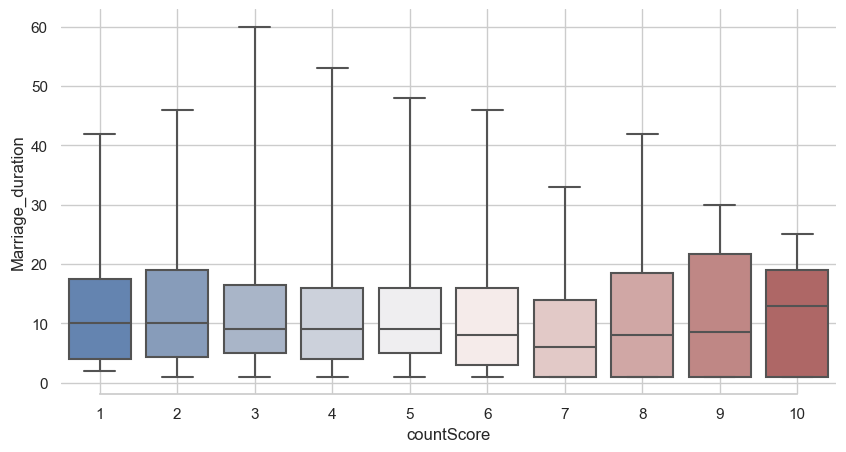

In [108]:
#for each countScore,plot the box plot of Marriage_duration 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(10, 5))

# Plot the total crashes
sns.set_color_codes("pastel")
sns.boxplot(x="countScore", y="Marriage_duration", data=df_filtered,
            whis=np.inf, palette="vlag")

# # Add in points to show each observation
# sns.stripplot(x="countScore", y="Marriage_duration", data=df_filtered,
#                 size=4, color=".3", linewidth=0)

# Tweak the visual presentation

ax.xaxis.grid(True)
ax.set(ylabel="Marriage_duration")
sns.despine(trim=True, left=True)

# plt.savefig('boxplot.png', dpi=300)
plt.show()





0 man日支同年支
1 man日支六沖
2 man日支六合
3 man財透干
4 man財得地
5 man日干五合
6 man日柱天地合
7 man流年雙體財
8 man日支半三合
9 man日支半三會局
10 man日支暗合
11 man流年大運天地合
12 man流年大運伏吟
13 man大運財透干
14 man大運財得地


C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_4392\4022221618.py:21: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from current font.
  plt.tight_layout()
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_4392\4022221618.py:21: UserWarning: Glyph 25903 (\N{CJK UNIFIED IDEOGRAPH-652F}) missing from current font.
  plt.tight_layout()
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_4392\4022221618.py:21: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from current font.
  plt.tight_layout()
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_4392\4022221618.py:21: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from current font.
  plt.tight_layout()
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_4392\4022221618.py:21: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}) missing from current font.
  plt.tight_layout()
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_4392\4022221618.py:21: UserWarning: Glyph 27798 (\N{CJK UNIFIED IDEOGRAPH-6C96}

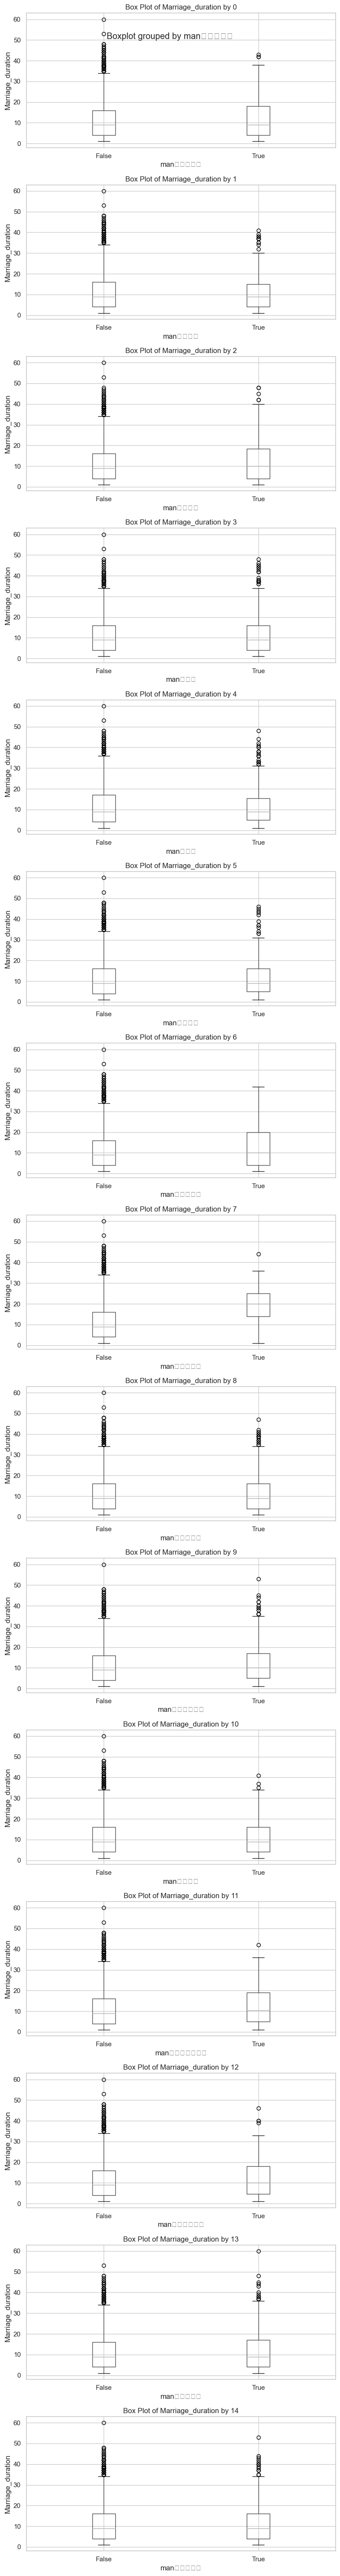

In [109]:
import matplotlib.pyplot as plt

# Assuming `man_df` is your DataFrame

# Get the boolean column names
bool_columns = [col for col in man_df.columns if man_df[col].dtype == bool]

# Create subplots to plot the box plots
fig, axes = plt.subplots(len(bool_columns), 1, figsize=(8, len(bool_columns)*4))

# Iterate over the boolean columns and plot box plots
for i, col in enumerate(bool_columns):
    print(i, col)
    ax = axes[i]
    man_df.boxplot(column='Marriage_duration', by=col, ax=ax)
    ax.set_xlabel(col)
    ax.set_ylabel('Marriage_duration')
    ax.set_title(f'Box Plot of Marriage_duration by {i}')

# Adjust the layout of subplots
plt.tight_layout()

# Display the plots
plt.show()


In [ ]:
#value counts of man流年天干十神 and man流年地支十神 combination then sort by count and calculate percentage
df_filtered.groupby(['man流年天干十神', 'man流年地支十神']).size().reset_index().rename(columns={0:'count'}).sort_values(by='count', ascending=False)
df_filtered.groupby(['man流年天干十神', 'man流年地支十神']).size().reset_index().rename(columns={0:'count'}).sort_values(by='count', ascending=False)
# create new df with only man流年天干十神 and man流年地支十神 combination and count and percentage named df_liunianshishen
df_liunianshishen = df_filtered.groupby(['man流年天干十神', 'man流年地支十神']).size().reset_index().rename(columns={0:'count'}).sort_values(by='count', ascending=False)
df_liunianshishen['percentage'] = df_liunianshishen['count'] / df_liunianshishen['count'].sum() * 100
df_liunianshishen

#calculate the everage Marriage_duration of each man流年天干十神 and man流年地支十神 combination then put it in new column named Avg_Marriage_duration of df_liunianshishen
df_liunianshishen['Avg_Marriage_duration'] = df_liunianshishen.apply(lambda x: df_filtered[(df_filtered['man流年天干十神'] == x['man流年天干十神']) & (df_filtered['man流年地支十神'] == x['man流年地支十神'])]['Marriage_duration'].mean(), axis=1)
df_liunianshishen

In [ ]:
#found out which combination is missing in df_liunianshishen
missing = []
for i in combination:
    if i not in list(zip(df_liunianshishen['man流年天干十神'], df_liunianshishen['man流年地支十神'])):
        missing.append(i)
missing

In [114]:
#count average of Marriage_duration for each bool column and print out the result, count only True
print(df_filtered[df_filtered['man日支同年支'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man日支六沖'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man日支六合'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man財透干'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man財得地'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man日干五合'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man日支半三合'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man日支半三會局'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man日支暗合'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man大運財透干'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man大運財得地'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man流年大運伏吟'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man日柱天地合'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man流年雙體財'] == True]['Marriage_duration'].mean())
print(df_filtered[df_filtered['man流年大運天地合'] == True]['Marriage_duration'].mean())






11.626373626373626
10.794721407624634
12.736543909348441
11.254022988505747
11.00890868596882
11.046511627906977
11.221649484536082
11.865535248041775
11.390557939914164
11.403740374037405
11.274440518256773
12.36
12.75
19.411214953271028
13.170454545454545


In [115]:
#for df_filtered[df_filtered['man流年雙體財'] == True],value count 當令 then get percentage
df_filtered[df_filtered['man流年雙體財'] == True]['當令'].value_counts() / df_filtered[df_filtered['man流年雙體財'] == True]['當令'].value_counts().sum() * 100
# df_filtered[df_filtered['man流年雙體財'] == True]['當令'].value_counts()


0    80.18018
1    19.81982
Name: 當令, dtype: float64

In [117]:
#value count 當令

df_filtered['當令'].value_counts()

#value count 當令 and percentage
df_filtered['當令'].value_counts() / df_filtered['當令'].count() * 100


0    79.982167
1    20.017833
Name: 當令, dtype: float64

In [212]:
df_filtered

,uniqueid,Divorce_date,Date_of_marriage,Age_partner_man,Marriage_duration,Type_of_divorce,Num_Children,DOB_partner_man,Level_of_education_partner_man,year_of_marriage,year_of_DOB,year_of_Divorse,month_of_DOB,day_of_DOB,DONE,dayun,man時干,man時支,man日干,man日支,man月干,man月支,man年干,man年支,Year_marriage_ganzhi,man日支同年支,man日支六沖,man日支六合,man流年天干十神,man流年地支十神,man財透干,man財得地,man日干五合,man日柱天地合,man流年雙體財,man日干支關係,man日支半三合,man日支半三會局,man日支暗合,man流年大運天地合,man流年大運伏吟,當令,man大運天干十神,man大運地支十神,man大運財透干,man大運財得地,man年干十神,man年支十神,man月干十神,man月支十神,年月有多少財,年月有多少官,本命日支六合,本命日支三合,本命日支被三合或六合,日支大運六合,日支大運三合,日支被大運三合或六合,流年之前日支被合,marriage_age,marri_age_group,man大運財透干2,man大運財得地2,man大運日支六沖,man大運日支六合,man大運日干五合,man大運日柱天地合,man財透干2,man財得地2,man流年大運地支伏吟
0,0,2006-06-09,2000-06-26,30.0,5.0,Necesario,1.0,1975-12-18,SECUNDARIA,2000,1975,2006,12,18,1,乙酉,壬,子,戊,戌,戊,子,乙,卯,庚辰,False,True,False,食神,比肩,False,False,False,False,False,比和,False,False,False,True,False,0,正官,傷官,False,False,正官,正官,比肩,正財,1,2,yes,no,yes,no,no,no,yes,25,21-30,False,False,False,False,False,False,False,False,False
1,1,2005-02-01,1975-12-18,49.0,NaN,Necesario,NaN,1955-02-22,PREPARATORIA,1975,1955,2005,2,22,1,丙子,甲,子,甲,寅,戊,寅,乙,未,乙卯,False,False,False,劫財,劫財,False,False,False,False,False,比和,False,True,False,False,False,1,食神,正印,False,False,劫財,正財,偏財,比肩,2,0,no,no,no,no,no,no,no,20,0-20,False,False,False,False,False,False,False,False,False
2,2,2006-02-01,1987-12-03,42.0,18.0,Necesario,2.0,1964-01-20,PROFESIONAL,1987,1964,2006,1,20,1,癸亥,壬,子,戊,辰,乙,丑,癸,卯,丁卯,False,False,False,正印,正官,False,False,False,False,False,比和,False,True,False,False,False,1,正財,偏財,True,True,正財,正官,正官,劫財,1,2,no,no,no,no,no,no,no,23,21-30,True,True,False,False,True,False,False,False,False
3,3,2006-02-01,1998-11-14,30.0,7.0,Necesario,2.0,1975-10-30,PROFESIONAL,1998,1975,2006,10,30,1,甲申,甲,子,己,酉,丙,戌,乙,卯,戊寅,False,False,False,劫財,正官,False,False,False,False,False,日干生日支,False,False,False,False,False,1,正官,傷官,False,False,七殺,七殺,正印,劫財,0,2,no,no,no,no,no,no,no,23,21-30,False,False,False,False,True,False,False,False,False
4,4,2006-02-01,1995-01-20,32.0,11.0,Necesario,2.0,1973-03-28,SECUNDARIA,1995,1973,2006,3,28,1,癸丑,壬,子,癸,亥,乙,卯,癸,丑,乙亥,True,False,False,食神,劫財,False,False,False,False,False,比和,False,False,False,False,False,0,比肩,七殺,False,False,比肩,七殺,食神,食神,0,1,no,no,no,no,no,no,no,22,21-30,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4537,4537,2012-10-31,2008-10-25,35.0,3.0,Voluntario,NaN,1977-10-29,PROFESIONAL,2008,1977,2012,10,29,1,丁未,甲,子,己,未,庚,戌,丁,巳,戊子,False,False,False,劫財,偏財,False,True,False,False,False,比和,False,False,False,False,False,1,偏印,比肩,False,False,偏印,偏印,傷官,劫財,0,0,no,no,no,no,no,no,no,31,21-30,False,False,False,False,False,False,False,True,False
4538,4538,2013-10-31,2012-05-26,30.0,1.0,Voluntario,NaN,1982-11-10,PROFESIONAL,2012,1982,2013,11,10,1,甲寅,庚,子,丁,酉,辛,亥,壬,戌,壬辰,False,False,True,正官,傷官,False,False,True,True,False,日干剋日支,False,False,False,False,False,0,正印,正印,False,False,正官,傷官,偏財,正官,1,2,no,no,no,no,no,no,no,30,21-30,False,False,False,False,False,False,False,False,False
4539,4539,2013-10-31,1978-06-02,59.0,35.0,Voluntario,2.0,1954-10-28,PROFESIONAL,1978,1954,2013,10,28,1,丁丑,庚,子,丁,巳,甲,戌,甲,午,戊午,False,False,False,傷官,劫財,False,False,False,False,False,比和,False,True,False,False,False,0,比肩,食神,False,False,正印,劫財,正印,傷官,0,0,no,no,no,no,no,no,no,24,21-30,False,False,False,False,False,False,False,False,False
4540,4540,2012-12-31,1979-11-05,54.0,33.0,Voluntario,2.0,1958-02-07,PREPARATORIA,1979,1958,2012,2,7,1,丙辰,丙,子,乙,卯,甲,寅,戊,戌,己未,False,False,False,偏財,偏財,True,True,False,False,True,比和,True,False,False,False,False,1,傷官,正財,False,True,正財,正財,劫財,劫財,2,0,yes,no,yes,no,no,no,yes,21,0-20,False,True,False,False,False,False,True,True,False


In [124]:
#for the columns that are boolean, count the number of True, and plot a bar chart to see the distribution
# create a list of columns that are boolean
boolean_cols = [col for col in df_filtered.columns if df_filtered[col].dtype == 'bool']
boolean_cols

# create a new df with only the boolean columns
df_bool = df_filtered[boolean_cols]
df_bool

# count the number of True and False in each column and show all the result
for col in df_bool.columns:
    print(col,df_bool[col].value_counts()[1])
    # print('-------------------')

# df_bool.sum()

# # plot a bar chart to see the distribution using plotly
import plotly.express as px
px.bar(df_bool.sum(), x=df_bool.sum().index, y=df_bool.sum().values)





man日支同年支 373
man日支六沖 355
man日支六合 364
man財透干 890
man財得地 924
man日干五合 441
man日柱天地合 78
man流年雙體財 111
man日支半三合 799
man日支半三會局 791
man日支暗合 242
man流年大運天地合 91
man流年大運伏吟 79
man大運財透干 937
man大運財得地 877


In [123]:
#for the columns that are boolean, count the number of True, and plot a bar chart to see the distribution
# create a list of columns that are boolean
boolean_cols = [col for col in df_filtered.columns if df_filtered[col].dtype == 'bool']
boolean_cols

# create a new df with only the boolean columns
df_bool = df_filtered[df_filtered['當令'] == 1][boolean_cols]
df_bool

# count the number of True and False in each column and show all the result
for col in df_bool.columns:
    print(col,df_bool[col].value_counts()[1])
    # print('-------------------')

# df_bool.sum()
#size 


# # plot a bar chart to see the distribution using plotly
import plotly.express as px

#graph size

px.bar(df_bool.sum(), x=df_bool.sum().index, y=df_bool.sum().values)


man日支同年支 80
man日支六沖 68
man日支六合 75
man財透干 191
man財得地 167
man日干五合 83
man日柱天地合 13
man流年雙體財 22
man日支半三合 150
man日支半三會局 139
man日支暗合 53
man流年大運天地合 17
man流年大運伏吟 14
man大運財透干 178
man大運財得地 138


In [125]:
#for the columns that are boolean, count the number of True, and plot a bar chart to see the distribution
# create a list of columns that are boolean
boolean_cols = [col for col in df_filtered.columns if df_filtered[col].dtype == 'bool']
boolean_cols

# create a new df with only the boolean columns
df_bool = df_filtered[df_filtered['當令'] == 0][boolean_cols]
df_bool

# count the number of True and False in each column and show all the result
for col in df_bool.columns:
    print(col,df_bool[col].value_counts()[1])
    # print('-------------------')

# df_bool.sum()

# # plot a bar chart to see the distribution using plotly
import plotly.express as px
px.bar(df_bool.sum(), x=df_bool.sum().index, y=df_bool.sum().values)


man日支同年支 293
man日支六沖 287
man日支六合 289
man財透干 699
man財得地 757
man日干五合 358
man日柱天地合 65
man流年雙體財 89
man日支半三合 649
man日支半三會局 652
man日支暗合 189
man流年大運天地合 74
man流年大運伏吟 65
man大運財透干 759
man大運財得地 739


# Analysis of eveyone liuniandayun 

In [55]:
#get all xls from C:\Users\TOSHIBA\Documents\Github\FateAi\Bazi Data Scraping and Analysis\fulldayun
import glob
import pandas as pd

path = r'C:\Users\TOSHIBA\Documents\Github\FateAi\Bazi Data Scraping and Analysis\fulldayun' # use your path
all_files = glob.glob(path + "/*.csv")



In [57]:
df_dayunliunian = pd.read_csv(all_files[0])

In [58]:
df_dayunliunian

,西元,實歲,大運,流年,大運流年合化,運勢 ( 紅線越長代表該年運勢越佳 ),bazi,uniqueid
0,1978,3,丁亥,戊午,NaN,NaN,壬子戊戌戊子乙卯,0
1,1979,4,丁亥,己未,地支木局,NaN,壬子戊戌戊子乙卯,0
2,1980,5,丁亥,庚申,NaN,NaN,壬子戊戌戊子乙卯,0
3,1981,6,丁亥,辛酉,NaN,NaN,壬子戊戌戊子乙卯,0
4,1982,7,丁亥,壬戌,天干化木,NaN,壬子戊戌戊子乙卯,0
...,...,...,...,...,...,...,...,...
76,2053,78,庚辰,癸酉,地支合金,NaN,壬子戊戌戊子乙卯,0
77,2054,79,庚辰,甲戌,地支土局,NaN,壬子戊戌戊子乙卯,0
78,2055,80,庚辰,乙亥,天干化金,NaN,壬子戊戌戊子乙卯,0
79,2056,81,庚辰,丙子,地支水局,NaN,壬子戊戌戊子乙卯,0


In [59]:
#drop 運勢 ( 紅線越長代表該年運勢越佳 )	
df_dayunliunian.drop('運勢 ( 紅線越長代表該年運勢越佳 )', axis=1, inplace=True)
df_dayunliunian

,西元,實歲,大運,流年,大運流年合化,bazi,uniqueid
0,1978,3,丁亥,戊午,NaN,壬子戊戌戊子乙卯,0
1,1979,4,丁亥,己未,地支木局,壬子戊戌戊子乙卯,0
2,1980,5,丁亥,庚申,NaN,壬子戊戌戊子乙卯,0
3,1981,6,丁亥,辛酉,NaN,壬子戊戌戊子乙卯,0
4,1982,7,丁亥,壬戌,天干化木,壬子戊戌戊子乙卯,0
...,...,...,...,...,...,...,...
76,2053,78,庚辰,癸酉,地支合金,壬子戊戌戊子乙卯,0
77,2054,79,庚辰,甲戌,地支土局,壬子戊戌戊子乙卯,0
78,2055,80,庚辰,乙亥,天干化金,壬子戊戌戊子乙卯,0
79,2056,81,庚辰,丙子,地支水局,壬子戊戌戊子乙卯,0


In [63]:
# Apply lambda function to extract values from 'bazi' column
df_dayunliunian[['man時干', 'man時支', 'man日干', 'man日支', 'man月干', 'man月支', 'man年干', 'man年支']] = df_dayunliunian['bazi'].apply(
    lambda x: [x[0], x[1], x[2], x[3], x[4], x[5], x[6], x[7]] if pd.notnull(x) else [np.nan] * 8
).apply(pd.Series)



In [67]:
#drop the row if 西元 not number
df_dayunliunian = df_dayunliunian[df_dayunliunian['西元'].apply(lambda x: x.isnumeric())]
df_dayunliunian


,西元,實歲,大運,流年,大運流年合化,bazi,uniqueid,man時干,man時支,man日干,man日支,man月干,man月支,man年干,man年支,man日支同年支,man日支六沖,man日支六合
0,1978,3,丁亥,戊午,NaN,壬子戊戌戊子乙卯,0,壬,子,戊,戌,戊,子,乙,卯,False,False,False
1,1979,4,丁亥,己未,地支木局,壬子戊戌戊子乙卯,0,壬,子,戊,戌,戊,子,乙,卯,False,False,False
2,1980,5,丁亥,庚申,NaN,壬子戊戌戊子乙卯,0,壬,子,戊,戌,戊,子,乙,卯,False,False,False
3,1981,6,丁亥,辛酉,NaN,壬子戊戌戊子乙卯,0,壬,子,戊,戌,戊,子,乙,卯,False,False,False
4,1982,7,丁亥,壬戌,天干化木,壬子戊戌戊子乙卯,0,壬,子,戊,戌,戊,子,乙,卯,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,2053,78,庚辰,癸酉,地支合金,壬子戊戌戊子乙卯,0,壬,子,戊,戌,戊,子,乙,卯,False,False,False
77,2054,79,庚辰,甲戌,地支土局,壬子戊戌戊子乙卯,0,壬,子,戊,戌,戊,子,乙,卯,True,False,False
78,2055,80,庚辰,乙亥,天干化金,壬子戊戌戊子乙卯,0,壬,子,戊,戌,戊,子,乙,卯,False,False,False
79,2056,81,庚辰,丙子,地支水局,壬子戊戌戊子乙卯,0,壬,子,戊,戌,戊,子,乙,卯,False,False,False


In [69]:
# 流年地支=流年[1]
# 流年天干=流年[0]
#日支伏吟
#if 流年[1] equal man日支, then True, else False, and create new column named man日支同年支
df_dayunliunian['man日支同年支'] = df_dayunliunian.apply(lambda row: True if row['man日支'] == row['流年'][1] else False, axis=1)
df_dayunliunian
#日支六沖
#if man日支 and 流年支 is liuchong, then True, else False, and create new column named man日支六沖
df_dayunliunian['man日支六沖'] = df_dayunliunian.apply(lambda row: is_liuchong(row['man日支'], row['流年'][1]), axis=1)


#日支六合
#if man日支 and 流年支 is_liuhe, then True, else False, and create new column named man日支六合
df_dayunliunian['man日支六合'] = df_dayunliunian.apply(lambda row: is_liuhe(row['man日支'], row['流年'][1]), axis=1)

# 流年天干十神
# create new column named man流年天干十神 using shi_shen function, and pass in col man日主 and col ['流年'][0]
df_dayunliunian['man流年天干十神'] = df_dayunliunian.apply(lambda x: shi_shen(x['man日干'], x['流年'][0]), axis=1)

# 流年地支十神
df_dayunliunian['man流年地支十神'] = df_dayunliunian.apply(lambda x: shi_shen(x['man日干'], x['流年'][1]), axis=1)


#財透干
#create new column named man財透干, if man流年天干十神 is 偏財 or 正財, then True, else False
df_dayunliunian['man財透干'] = df_dayunliunian['man流年天干十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)

#財得地
#create new column named man財得地, if man流年地支十神 is 偏財 or 正財, then True, else False
df_dayunliunian['man財得地'] = df_dayunliunian['man流年地支十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)

#大運流年天地合


#流年有傷官

#日干五合
# create new column named man日干五合, if man日干 and 流年天干 is is_wuhe, then True, else False
df_dayunliunian['man日干五合'] = df_dayunliunian.apply(lambda row: is_wuhe(row['man日干'], row['流年'][0]), axis=1)



#流年日柱天地合
#if man日支六合 is True and man日干五合 is true, then True, else False
df_dayunliunian['man日柱天地合'] = df_dayunliunian.apply(lambda row: True if row['man日支六合'] and row['man日干五合'] else False, axis=1)

#流年雙體財
df_dayunliunian['man流年雙體財'] = df_dayunliunian.apply(lambda row: True if row['man財透干'] and row['man財得地'] else False, axis=1)
# create new column named man日干支關係 using gan_zhi_relation function, and pass in col man日干 and col man日支
df_dayunliunian['man日干支關係'] = df_dayunliunian.apply(lambda row: gan_zhi_relation(row['man日干'], row['man日支']), axis=1)

    
#create new col named man日支半三合, if man日支 和 流年支 is 半三合, then True, else False
df_dayunliunian['man日支半三合'] = df_dayunliunian.apply(lambda row: check_halfsanhe(row['man日支'], row['流年'][1]), axis=1)

    
#create new col named man日支半三合, if man日支 和 流年支 is 半三合, then True, else False
df_dayunliunian['man日支半三會局'] = df_dayunliunian.apply(lambda row: check_halfsanhuì(row['man日支'], row['流年'][1]), axis=1)

   
#日支六合
#if man日支 and 流年支 is_liuhe, then True, else False, and create new column named man日支六合
df_dayunliunian['man日支暗合'] = df_dayunliunian.apply(lambda row: check_anhe(row['man日支'], row['流年'][1]), axis=1)


# # create new column named man流年大運伏吟 if 流年=大運, then True, else False
df_dayunliunian['man流年大運伏吟'] = df_dayunliunian.apply(lambda row: True if row['流年'] == row['大運'] else False, axis=1)
    
df_dayunliunian['man流年大運天地合'] = df_dayunliunian.apply(lambda row: check_tiandihe(row['流年'], row['大運']), axis=1)

C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11400\185991433.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11400\185991433.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11400\185991433.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

In [107]:

df_dayunliunian['man流年大運天地合'] = df_dayunliunian.apply(lambda row: check_tiandihe(row['流年'], row['大運']), axis=1)

C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11400\3046105275.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [117]:
#get uniqueid of first row
uniqueid = df_dayunliunian.iloc[0]['uniqueid']

#genzi = Year_marriage_ganzhi of the row of unique id in df_filtered
ganzi = df_filtered[df_filtered['uniqueid'] == uniqueid]['Year_marriage_ganzhi'].values[0]
#create a new column named marriage, if 流年=辛酉, then marriage = True, else False
df_dayunliunian['marriage'] = df_dayunliunian['流年'].apply(lambda x: "yes" if x == ganzi else "no")

C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11400\696404653.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [118]:
#create new col named countScore, count how many true in that row
df_dayunliunian['countScore'] = df_dayunliunian.apply(lambda x: sum(x == True), axis=1)

C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11400\4135750496.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [119]:
#value count of bool columns and print out the True count only
for col in df_dayunliunian.columns:
    if df_dayunliunian[col].dtype == 'bool':
        #print out the column name
        print(col)
        print(df_dayunliunian[col].value_counts())

man日支同年支
False    73
True     7 
Name: man日支同年支, dtype: int64
man日支六沖
False    74
True     6 
Name: man日支六沖, dtype: int64
man日支六合
False    74
True     6 
Name: man日支六合, dtype: int64
man財透干
False    64
True     16
Name: man財透干, dtype: int64
man財得地
False    66
True     14
Name: man財得地, dtype: int64
man日干五合
False    72
True     8 
Name: man日干五合, dtype: int64
man日柱天地合
False    79
True     1 
Name: man日柱天地合, dtype: int64
man流年雙體財
False    77
True     3 
Name: man流年雙體財, dtype: int64
man日支半三合
False    67
True     13
Name: man日支半三合, dtype: int64
man日支半三會局
False    66
True     14
Name: man日支半三會局, dtype: int64
man日支暗合
False    80
Name: man日支暗合, dtype: int64
man流年大運伏吟
False    79
True     1 
Name: man流年大運伏吟, dtype: int64
man流年大運天地合
False    79
True     1 
Name: man流年大運天地合, dtype: int64


In [120]:
# value count of bool columns and print out the True count only if marriage is True
for col in df_dayunliunian.columns:
    if df_dayunliunian[col].dtype == 'bool':
        # if 'marriage' in df_dayunliunian.columns:
            
        true_count = df_dayunliunian[df_dayunliunian['marriage'] == "yes"][col].value_counts().get(True, 0)
        # else:
            # true_count = df_dayunliunian[col].value_counts().get(True, 0)
        print(col)
        print(true_count)


man日支同年支
0
man日支六沖
1
man日支六合
0
man財透干
0
man財得地
0
man日干五合
0
man日柱天地合
0
man流年雙體財
0
man日支半三合
0
man日支半三會局
0
man日支暗合
0
man流年大運伏吟
0
man流年大運天地合
1


In [91]:
# value count of bool columns and get the col name and put it in a string if it is True, only for the row if marriage is True


trueCount = ''
for col in df_dayunliunian.columns:
    if df_dayunliunian[col].dtype == 'bool':
        # if 'marriage' in df_dayunliunian.columns:
            
        true_count = df_dayunliunian[df_dayunliunian['marriage'] == "yes"][col].value_counts().get(True, 0)
        # else:
            # true_count = df_dayunliunian[col].value_counts().get(True, 0)
        if true_count > 0:
            # print(col)
            if col != 'marriage':
                trueCount += col + ','



print(trueCount)

man日支六沖,


In [121]:
#create new col named trueCount, value count of bool columns and get the col name and put it in a string if it is True
df_dayunliunian['trueCount'] = df_dayunliunian.apply(lambda x: ','.join([col for col in df_dayunliunian.columns if df_dayunliunian[col].dtype == 'bool' and x[col] == True]), axis=1)

C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11400\657386420.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [122]:
#create new col named trueCountAnd大運流年合化, add 大運流年合化 to trueCount if 大運流年合化 is not NaN
df_dayunliunian['trueCountAnd大運流年合化'] = df_dayunliunian.apply(lambda x: x['trueCount'] +","+x['大運流年合化'] if not pd.isnull(x['大運流年合化']) else x['trueCount'], axis=1)


C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11400\1041277860.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [138]:
import pandas as pd
import plotly.graph_objs as go
#get the bazi of the first row
bazi = df_dayunliunian['bazi'][0]

# read in the data as a pandas dataframe

# create a bar chart with x and y values
fig = go.Figure(data=[
                    go.Bar(x=df_dayunliunian['西元'], y=df_dayunliunian['countScore'],
                                name='countScore',
                                text=df_dayunliunian["trueCountAnd大運流年合化"]+df_dayunliunian['實歲'],
                                marker=dict(color='blue')),
                     ])

# annotations = []
for i, marriage in enumerate(df_dayunliunian['marriage']):
    if marriage == "yes":

        fig.add_trace(go.Scatter(x=[df_dayunliunian['西元'][i]], y=[df_dayunliunian['countScore'][i]], 
                                 mode='markers', 
                                #  text=df_dayunliunian['trueCount'][i],
                                 marker=dict(color='red', size=8)))

# fig.update_layout(annotations=annotations)

# update the layout
fig.update_layout(title=f'大運流年分析 {bazi}', xaxis_title='西元', yaxis_title='countScore',
                  xaxis=dict(tickmode='linear', tick0=0))
# set fig size
fig.update_layout(width=1000, height=400)
# show the plot
fig.show()


In [147]:
#for first 10 files in all_files
# for filename in all_files[:10]:
# df_dayunliunian
for i in range (10):
    print(i)

0
1
2
3
4
5
6
7
8
9


In [ ]:
#print number from 1 to 10
for i in range (1, 11):
    

In [85]:
import pandas as pd
import plotly.graph_objs as go

In [87]:
df_filtered[df_filtered['uniqueid'] == uniqueid]['year_of_marriage']

29    2001
Name: year_of_marriage, dtype: int64

In [190]:
df_dayunliunian

,西元,實歲,大運,流年,大運流年合化,bazi,uniqueid,man時干,man時支,man日干,man日支,man月干,man月支,man年干,man年支,man日支同年支,man日支六沖,man大運日支六沖,man日支六合,man大運日支六合,man流年天干十神,man流年地支十神,man財透干,man財透干2,man財得地,man財得地2,man日干五合,man大運日干五合,man日柱天地合,man大運日柱天地合,man流年雙體財,man日干支關係,man日支半三合,man日支半三會局,man日支暗合,man流年大運伏吟,man流年大運地支伏吟,man流年大運天地合,man大運天干十神,man大運地支十神,man大運財透干,man大運財透干2,man大運財得地,man大運財得地2,man大運雙體財,man年干十神,man年支十神,man月干十神,man月支十神,年月有多少財,年月有多少官,本命日支六合,本命日支三合,本命日支被三合或六合,日支大運三合,日支大運流年三合,日支被大運三合或六合,流年之前日支被合,marriage,divorse,countScore,trueCount,trueCountAnd大運流年合化
0,1981,8,甲寅,辛酉,NaN,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,True,False,False,False,False,食神,食神,False,False,False,False,False,True,False,False,False,日干生日支,False,False,False,False,False,False,正官,正官,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,2,"man日支同年支,man大運日干五合","man日支同年支,man大運日干五合"
1,1982,9,甲寅,壬戌,地支火局,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,正財,劫財,True,True,False,False,False,True,False,False,False,日干生日支,False,True,False,False,False,False,正官,正官,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,4,"man財透干,man財透干2,man大運日干五合,man日支半三會局","man財透干,man財透干2,man大運日干五合,man日支半三會局,地支火局"
2,1983,10,甲寅,癸亥,地支合木,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,偏財,正財,True,True,True,True,False,True,False,False,True,日干生日支,False,False,False,False,False,False,正官,正官,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,6,"man財透干,man財透干2,man財得地,man財得地2,man大運日干五合,man流年雙體財","man財透干,man財透干2,man財得地,man財得地2,man大運日干五合,man流年雙體財,地支合木"
3,1984,11,甲寅,甲子,NaN,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,正官,偏財,False,False,True,True,True,True,False,False,False,日干生日支,False,False,False,False,False,False,正官,正官,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,4,"man財得地,man財得地2,man日干五合,man大運日干五合","man財得地,man財得地2,man日干五合,man大運日干五合"
4,1985,12,甲寅,乙丑,NaN,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,七殺,比肩,False,False,False,False,False,True,False,False,False,日干生日支,True,False,False,False,False,False,正官,正官,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,2,"man大運日干五合,man日支半三合","man大運日干五合,man日支半三合"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2056,83,辛酉,丙子,天干化水,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,正印,偏財,False,False,True,True,False,False,False,False,False,日干生日支,False,False,False,False,False,False,食神,食神,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,2,"man財得地,man財得地2","man財得地,man財得地2,天干化水"
76,2057,84,辛酉,丁丑,地支金局,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,偏印,比肩,False,False,False,False,False,False,False,False,False,日干生日支,True,False,False,False,False,False,食神,食神,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,1,man日支半三合,"man日支半三合,地支金局"
77,2058,85,辛酉,戊寅,NaN,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,劫財,正官,False,False,False,False,False,False,False,False,False,日干生日支,False,False,False,False,False,False,食神,食神,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,0,,
78,2059,86,辛酉,己卯,NaN,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,True,False,False,False,比肩,七殺,False,False,False,False,False,False,False,False,False,日干生日支,False,False,False,False,False,False,食神,食神,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,1,man日支六沖,man日支六沖


In [208]:
# from col df_dayunliunian['大運流年合化'] , which is a string colume, the string is something like 'xxxx地支金局xxxxx', x is other char with unknown length 
# for each row, get char from 地支 to 局
# return the 2nd char then put it to a new col, named '大運流年合化屬性'

df_dayunliunian['大運流年合化屬性'] = df_dayunliunian['大運流年合化'].str.extract('(地支.*局)')

df_dayunliunian['大運流年合化屬性'] = df_dayunliunian['大運流年合化屬性'].str[2]

#create a new col named '日干屬性' use man日干 and wu_xing_dict
df_dayunliunian['日干屬性'] = df_dayunliunian['man日干'].apply(lambda x: wu_xing_dict[x])

ke_dict = {
    '金': ['木'],
    '木': ['土'],
    '水': ['火'],
    '火': ['金'],
    '土': ['水']
}
#金 剋 木

sheng_dict = {
    '金': ['水'],
    '木': ['火'],
    '水': ['木'],
    '火': ['土'],
    '土': ['金']
}
#金 生 水

#create a new col named '合化十神' use col 大運流年合化屬性 and col 日干屬性, use ke_dict and sheng_dict
# if 大運流年合化屬性 生 日干屬性 then 合化十神 = 印
# if 大運流年合化屬性 = 日干屬性 then 合化十神 = 比
# if 大運流年合化屬性 剋 日干屬性 then 合化十神 = 官殺
# if 日干屬性 生 大運流年合化屬性 then 合化十神 = 食傷
# if 日干屬性 剋 大運流年合化屬性 then 合化十神 = 財
# Define the function to determine '合化十神' based on '大運流年合化屬性' and '日干屬性'
def determine_hehua(row):
    duan_attr = row['大運流年合化屬性']
    ri_attr = row['日干屬性']
    
    if sheng_dict.get(duan_attr) == [ri_attr]:
        return '印'
    elif duan_attr == ri_attr:
        return '比'
    elif ke_dict.get(duan_attr) == [ri_attr]:
        return '官殺'
    elif sheng_dict.get(ri_attr) == [duan_attr]:
        return '食傷'
    elif ke_dict.get(ri_attr) == [duan_attr]:
        return '財'
    else:
        return None

# Apply the function to create the '合化十神' column
df_dayunliunian['合化十神'] = df_dayunliunian.apply(determine_hehua, axis=1)

# create a new col named '合化十神TF' use col 合化十神
# if 合化十神 = '印' or 財 or 食傷 then True else False
df_dayunliunian['合化十神TF'] = df_dayunliunian['合化十神'].apply(lambda x: True if x in ['印', '財', '食傷'] else False)


In [209]:
df_dayunliunian



import plotly.graph_objs as go
#for all files in all_files
# for i in range (0, 20):
for i in showlist[0:10]:
    df_dayunliunian = pd.read_csv(f'C:\\Users\\TOSHIBA\\Documents\\Github\\FateAi\\Bazi Data Scraping and Analysis\\fulldayun\\{i}fulldayun.csv')
    df_dayunliunian.drop('運勢 ( 紅線越長代表該年運勢越佳 )', axis=1, inplace=True)
    df_dayunliunian[['man時干', 'man時支', 'man日干', 'man日支', 'man月干', 'man月支', 'man年干', 'man年支']] = df_dayunliunian['bazi'].apply(
    lambda x: [x[0], x[1], x[2], x[3], x[4], x[5], x[6], x[7]] if pd.notnull(x) else [np.nan] * 8
    ).apply(pd.Series)
    #drop the row if 西元 not number
    df_dayunliunian = df_dayunliunian[df_dayunliunian['西元'].apply(lambda x: x.isnumeric())]
    #reset index
    df_dayunliunian.reset_index(inplace=True, drop=True)

    #######################
    # 流年地支=流年[1]
    # 流年天干=流年[0]
    #日支伏吟
    #if 流年[1] equal man日支, then True, else False, and create new column named man日支同年支
    df_dayunliunian['man日支同年支'] = df_dayunliunian.apply(lambda row: True if row['man日支'] == row['流年'][1] else False, axis=1)
    df_dayunliunian
    #日支六沖
    #if man日支 and 流年支 is liuchong, then True, else False, and create new column named man日支六沖
    df_dayunliunian['man日支六沖'] = df_dayunliunian.apply(lambda row: is_liuchong(row['man日支'], row['流年'][1]), axis=1)
    df_dayunliunian['man大運日支六沖'] = df_dayunliunian.apply(lambda row: is_liuchong(row['man日支'], row['大運'][1]), axis=1)##大運
    #日支六合
    #if man日支 and 流年支 is_liuhe, then True, else False, and create new column named man日支六合
    df_dayunliunian['man日支六合'] = df_dayunliunian.apply(lambda row: is_liuhe(row['man日支'], row['流年'][1]), axis=1)
    df_dayunliunian['man大運日支六合'] = df_dayunliunian.apply(lambda row: is_liuhe(row['man日支'], row['大運'][1]), axis=1)##大運
    # 流年天干十神
    # create new column named man流年天干十神 using shi_shen function, and pass in col man日主 and col ['流年'][0]
    df_dayunliunian['man流年天干十神'] = df_dayunliunian.apply(lambda x: shi_shen(x['man日干'], x['流年'][0]), axis=1)
    # 流年地支十神
    df_dayunliunian['man流年地支十神'] = df_dayunliunian.apply(lambda x: shi_shen(x['man日干'], x['流年'][1]), axis=1)
    #財透干
    #create new column named man財透干, if man流年天干十神 is 偏財 or 正財, then True, else False
    df_dayunliunian['man財透干'] = df_dayunliunian['man流年天干十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
    df_dayunliunian['man財透干2'] = df_dayunliunian['man流年天干十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
    #財得地
    #create new column named man財得地, if man流年地支十神 is 偏財 or 正財, then True, else False
    df_dayunliunian['man財得地'] = df_dayunliunian['man流年地支十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
    df_dayunliunian['man財得地2'] = df_dayunliunian['man流年地支十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
    #流年有傷官
    #日干五合
    # create new column named man日干五合, if man日干 and 流年天干 is is_wuhe, then True, else False
    df_dayunliunian['man日干五合'] = df_dayunliunian.apply(lambda row: is_wuhe(row['man日干'], row['流年'][0]), axis=1)
    df_dayunliunian['man大運日干五合'] = df_dayunliunian.apply(lambda row: is_wuhe(row['man日干'], row['大運'][0]), axis=1)##大運
    #流年日柱天地合
    #if man日支六合 is True and man日干五合 is true, then True, else False
    df_dayunliunian['man日柱天地合'] = df_dayunliunian.apply(lambda row: True if row['man日支六合'] and row['man日干五合'] else False, axis=1)
    df_dayunliunian['man大運日柱天地合'] = df_dayunliunian.apply(lambda row: True if row['man大運日支六合'] and row['man大運日干五合'] else False, axis=1)##大運
    #流年雙體財
    df_dayunliunian['man流年雙體財'] = df_dayunliunian.apply(lambda row: True if row['man財透干'] and row['man財得地'] else False, axis=1)
    # create new column named man日干支關係 using gan_zhi_relation function, and pass in col man日干 and col man日支
    df_dayunliunian['man日干支關係'] = df_dayunliunian.apply(lambda row: gan_zhi_relation(row['man日干'], row['man日支']), axis=1)
    #create new col named man日支半三合, if man日支 和 流年支 is 半三合, then True, else False
    df_dayunliunian['man日支半三合'] = df_dayunliunian.apply(lambda row: check_halfsanhe(row['man日支'], row['流年'][1]), axis=1)
    #create new col named man日支半三合, if man日支 和 流年支 is 半三合, then True, else False
    df_dayunliunian['man日支半三會局'] = df_dayunliunian.apply(lambda row: check_halfsanhuì(row['man日支'], row['流年'][1]), axis=1)
    #日支六合
    #if man日支 and 流年支 is_liuhe, then True, else False, and create new column named man日支六合
    df_dayunliunian['man日支暗合'] = df_dayunliunian.apply(lambda row: check_anhe(row['man日支'], row['流年'][1]), axis=1)
    # # create new column named man流年大運伏吟 if 流年=大運, then True, else False
    df_dayunliunian['man流年大運伏吟'] = df_dayunliunian.apply(lambda row: True if row['流年'] == row['大運'] else False, axis=1)
    df_dayunliunian['man流年大運地支伏吟'] = df_dayunliunian.apply(lambda row: True if row['流年'][1] == row['大運'][1] else False, axis=1)
    df_dayunliunian['man流年大運天地合'] = df_dayunliunian.apply(lambda row: check_tiandihe(row['流年'], row['大運']), axis=1)

    # dayun天干十神
    # create new column named mandayun天干十神 using shi_shen function, and pass in col man日主 and col ['Year_marriage_ganzhi'][0]
    df_dayunliunian['man大運天干十神'] = df_dayunliunian.apply(lambda x: shi_shen(x['man日干'], x['大運'][0]), axis=1)

    # dayun地支十神
    df_dayunliunian['man大運地支十神'] = df_dayunliunian.apply(lambda x: shi_shen(x['man日干'], x['大運'][1]), axis=1)


    #財透干
    #create new column named man財透干, if man流年天干十神 is 偏財 or 正財, then True, else False
    df_dayunliunian['man大運財透干'] = df_dayunliunian['man大運天干十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
    df_dayunliunian['man大運財透干2'] = df_dayunliunian['man大運天干十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
    #財得地
    #create new column named man財得地, if man流年地支十神 is 偏財 or 正財, then True, else False
    df_dayunliunian['man大運財得地'] = df_dayunliunian['man大運地支十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
    df_dayunliunian['man大運財得地2'] = df_dayunliunian['man大運地支十神'].apply(lambda x: True if x in ['偏財', '正財'] else False)
    df_dayunliunian['man大運雙體財'] = df_dayunliunian.apply(lambda row: True if row['man大運財透干'] and row['man大運財得地'] else False, axis=1)##大運
    #年柱有財
    # dayun天干十神
    # create new column named mandayun天干十神 using shi_shen function, and pass in col man日主 and col ['Year_marriage_ganzhi'][0]
    df_dayunliunian['man年干十神'] = df_dayunliunian.apply(lambda x: shi_shen(x['man日干'], x['man年干']), axis=1)


    df_dayunliunian['man年支十神'] = df_dayunliunian.apply(lambda x: shi_shen(x['man日干'], x['man年支']), axis=1)

    df_dayunliunian['man月干十神'] = df_dayunliunian.apply(lambda x: shi_shen(x['man日干'], x['man月干']), axis=1)


    df_dayunliunian['man月支十神'] = df_dayunliunian.apply(lambda x: shi_shen(x['man日干'], x['man月支']), axis=1)

    #create new column named 年月有多少財
    #count number of 財 in man年干十神 and man年支十神 and man月干十神 and man月支十神 and put the number in new column called 年月有多少財
    #is 財 if x in ['偏財', '正財']
    wealth_characters = ['偏財', '正財']
    df_dayunliunian['年月有多少財'] = df_dayunliunian[['man年干十神', 'man年支十神', 'man月干十神', 'man月支十神']].apply(lambda x: sum(1 for char in x if char in wealth_characters), axis=1)

    guan_characters =['正官', '七殺']
    df_dayunliunian['年月有多少官'] = df_dayunliunian[['man年干十神', 'man年支十神', 'man月干十神', 'man月支十神']].apply(lambda x: sum(1 for char in x if char in guan_characters), axis=1)
    #本命日支被合
    #create a new col named in df_dayunliunian called 本命日支被合, if is_liuhe(man日支, man月支) or is_liuhe(man日支, man年支) then yes, else no
    #I have the function is_liuhe(str1, str2) above
    df_dayunliunian['本命日支六合'] = df_dayunliunian.apply(lambda x: 'yes' if is_liuhe(x['man日支'], x['man月支']) or is_liuhe(x['man日支'], x['man年支']) else 'no', axis=1)

    # check_sanhe
    df_dayunliunian['本命日支三合'] = df_dayunliunian.apply(lambda x: 'yes' if check_sanhe(x['man日支'], x['man月支'],x['man年支']) else 'no', axis=1)


    df_dayunliunian['本命日支被三合或六合'] = df_dayunliunian.apply(lambda x: 'yes' if (x['本命日支六合'] == 'yes') or (x['本命日支三合'] == 'yes') else 'no', axis=1)
    #日支大運六合

    # df_dayunliunian['日支大運六合'] = df_dayunliunian.apply(lambda x: True if is_liuhe(x['man日支'], x['大運'][1]) else False, axis=1)
    #日支大運三合

    #sanhe
    df_dayunliunian['日支大運三合']= df_dayunliunian.apply(lambda x: True if check_sanhe(x['man日支'], x['man月支'],x['大運'][1]) or check_sanhe(x['man日支'], x['man年支'],x['大運'][1]) else False, axis=1)
    # df_dayunliunian['日支大運三合屬性']

    df_dayunliunian['日支大運流年三合'] = df_dayunliunian.apply(lambda x: True if check_sanhe(x['man日支'], x['大運'][1],x['流年'][1]) else False, axis=1)
    # df_dayunliunian['日支大運流年三合屬性']

    # df_dayunliunian['年支大運流年三合屬性']
    # df_dayunliunian['月支大運流年三合屬性']
    # df_dayunliunian['月支年支流年三合屬性']


    #sanhe

    #地支x局
    df_dayunliunian['大運流年合化屬性'] = df_dayunliunian['大運流年合化'].str.extract('(地支.*局)')

    df_dayunliunian['大運流年合化屬性'] = df_dayunliunian['大運流年合化屬性'].str[2]

    #create a new col named '日干屬性' use man日干 and wu_xing_dict
    df_dayunliunian['日干屬性'] = df_dayunliunian['man日干'].apply(lambda x: wu_xing_dict[x])
    # Apply the function to create the '合化十神' column
    df_dayunliunian['合化十神'] = df_dayunliunian.apply(determine_hehua, axis=1)

    # create a new col named '合化十神TF' use col 合化十神
    # if 合化十神 = '印' or 財 or 食傷 then True else False
    df_dayunliunian['合化十神TF'] = df_dayunliunian['合化十神'].apply(lambda x: True if x in ['印', '食傷'] else False)
    #地支x局

    df_dayunliunian['日支被大運三合或六合'] = df_dayunliunian.apply(lambda x: 'yes' if (x['man大運日支六合'] == True) or (x['日支大運三合'] == True) else 'no', axis=1)

    #流年之前日支被合
    df_dayunliunian['流年之前日支被合'] = df_dayunliunian.apply(lambda x: 'yes' if (x['本命日支被三合或六合'] == 'yes') or (x['日支被大運三合或六合'] == 'yes') else 'no', axis=1)


    #convert 西元 to int
    df_dayunliunian['西元'] = df_dayunliunian['西元'].astype(int)
    #get uniqueid of first row
    uniqueid = df_dayunliunian.iloc[0]['uniqueid']

    #genzi = Year_marriage_ganzhi of the row of unique id in df_filtered
    year_of_marriage= df_filtered[df_filtered['uniqueid'] == uniqueid]['year_of_marriage'].values[0]
    #create a new column named marriage, if 流年=辛酉, then marriage = True, else False
    df_dayunliunian['marriage'] = df_dayunliunian['西元'].apply(lambda x: "yes" if x == year_of_marriage else "no")
    year_of_divorce = df_filtered[df_filtered['uniqueid'] == uniqueid]['year_of_Divorse'].values[0]
    #create a new column named marriage, if 流年=辛酉, then marriage = True, else False
    df_dayunliunian['divorse'] = df_dayunliunian['西元'].apply(lambda x: "yes" if x == year_of_divorce else "no")
    #create new col named countScore, count how many true in that row
    df_dayunliunian['countScore'] = df_dayunliunian.apply(lambda x: sum(x == True), axis=1)
    #create new col named trueCount, value count of bool columns and get the col name and put it in a string if it is True
    df_dayunliunian['trueCount'] = df_dayunliunian.apply(lambda x: ','.join([col for col in df_dayunliunian.columns if df_dayunliunian[col].dtype == 'bool' and x[col] == True]), axis=1)
    #create new col named trueCountAnd大運流年合化, add 大運流年合化 to trueCount if 大運流年合化 is not NaN
    df_dayunliunian['trueCountAnd大運流年合化'] = df_dayunliunian.apply(lambda x: x['trueCount'] +","+x['大運流年合化'] if not pd.isnull(x['大運流年合化']) else x['trueCount'], axis=1)

    


    #get the bazi of the first row
    

    # read in the data as a pandas dataframe

    # create a bar chart with x and y values
    fig = go.Figure(data=[
                        go.Bar(x=df_dayunliunian['西元'], y=df_dayunliunian['countScore'],
                                    name='countScore',
                                    text=df_dayunliunian["trueCountAnd大運流年合化"]+df_dayunliunian['實歲'] + df_dayunliunian['大運'] + df_dayunliunian['流年'],
                                    marker=dict(color='blue')),
                        ])

    # annotations = []
    for i, marriage in enumerate(df_dayunliunian['marriage']):
        if marriage == "yes":

            fig.add_trace(go.Scatter(x=[df_dayunliunian['西元'][i]], y=[df_dayunliunian['countScore'][i]], 
                                    mode='markers', 
                                    #  text=df_dayunliunian['trueCount'][i],
                                    # text=df_dayunliunian["大運"][i]+df_dayunliunian['流年'][i],
                                    marker=dict(color='red', size=8)))
        if df_dayunliunian['divorse'][i] == "yes":
            fig.add_trace(go.Scatter(x=[df_dayunliunian['西元'][i]], y=[df_dayunliunian['countScore'][i]], 
                                    mode='markers', 
                                    #  text=df_dayunliunian['trueCount'][i],
                                    # text=df_dayunliunian["大運"][i]+df_dayunliunian['流年'][i],
                                    marker=dict(color='green', size=8)))

    # fig.update_layout(annotations=annotations)
    bazi = df_dayunliunian['bazi'][0]
    日主 = df_dayunliunian['man日干'][0]
    月令 = df_dayunliunian['man月支'][0]
    uniqueid = df_dayunliunian['uniqueid'][0]
    # update the layout
    fig.update_layout(title=f'大運流年分析 {bazi} 日主: {日主} 月令: {月令} ID: {uniqueid} MY: {year_of_marriage} DY: {year_of_divorce}', xaxis_title='西元', yaxis_title='countScore',
                    xaxis=dict(tickmode='linear', tick0=0))
    # set fig size
    fig.update_layout(width=1000, height=400)
    # show the plot
    fig.show()

,西元,實歲,大運,流年,大運流年合化,bazi,uniqueid,man時干,man時支,man日干,man日支,man月干,man月支,man年干,man年支,man日支同年支,man日支六沖,man大運日支六沖,man日支六合,man大運日支六合,man流年天干十神,man流年地支十神,man財透干,man財透干2,man財得地,man財得地2,man日干五合,man大運日干五合,man日柱天地合,man大運日柱天地合,man流年雙體財,man日干支關係,man日支半三合,man日支半三會局,man日支暗合,man流年大運伏吟,man流年大運地支伏吟,man流年大運天地合,man大運天干十神,man大運地支十神,man大運財透干,man大運財透干2,man大運財得地,man大運財得地2,man大運雙體財,man年干十神,man年支十神,man月干十神,man月支十神,年月有多少財,年月有多少官,本命日支六合,本命日支三合,本命日支被三合或六合,日支大運三合,日支大運流年三合,日支被大運三合或六合,流年之前日支被合,marriage,divorse,countScore,trueCount,trueCountAnd大運流年合化,大運流年合化屬性,日干屬性,合化十神,合化十神TF
0,1981,8,甲寅,辛酉,NaN,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,True,False,False,False,False,食神,食神,False,False,False,False,False,True,False,False,False,日干生日支,False,False,False,False,False,False,正官,正官,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,2,"man日支同年支,man大運日干五合","man日支同年支,man大運日干五合",NaN,土,None,False
1,1982,9,甲寅,壬戌,地支火局,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,正財,劫財,True,True,False,False,False,True,False,False,False,日干生日支,False,True,False,False,False,False,正官,正官,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,4,"man財透干,man財透干2,man大運日干五合,man日支半三會局","man財透干,man財透干2,man大運日干五合,man日支半三會局,地支火局",火,土,印,True
2,1983,10,甲寅,癸亥,地支合木,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,偏財,正財,True,True,True,True,False,True,False,False,True,日干生日支,False,False,False,False,False,False,正官,正官,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,6,"man財透干,man財透干2,man財得地,man財得地2,man大運日干五合,man流年雙體財","man財透干,man財透干2,man財得地,man財得地2,man大運日干五合,man流年雙體財,地支合木",NaN,土,None,False
3,1984,11,甲寅,甲子,NaN,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,正官,偏財,False,False,True,True,True,True,False,False,False,日干生日支,False,False,False,False,False,False,正官,正官,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,4,"man財得地,man財得地2,man日干五合,man大運日干五合","man財得地,man財得地2,man日干五合,man大運日干五合",NaN,土,None,False
4,1985,12,甲寅,乙丑,NaN,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,七殺,比肩,False,False,False,False,False,True,False,False,False,日干生日支,True,False,False,False,False,False,正官,正官,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,2,"man大運日干五合,man日支半三合","man大運日干五合,man日支半三合",NaN,土,None,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2056,83,辛酉,丙子,天干化水,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,正印,偏財,False,False,True,True,False,False,False,False,False,日干生日支,False,False,False,False,False,False,食神,食神,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,2,"man財得地,man財得地2","man財得地,man財得地2,天干化水",NaN,土,None,False
76,2057,84,辛酉,丁丑,地支金局,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,偏印,比肩,False,False,False,False,False,False,False,False,False,日干生日支,True,False,False,False,False,False,食神,食神,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,1,man日支半三合,"man日支半三合,地支金局",金,土,食傷,True
77,2058,85,辛酉,戊寅,NaN,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,False,False,False,False,劫財,正官,False,False,False,False,False,False,False,False,False,日干生日支,False,False,False,False,False,False,食神,食神,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,0,,,NaN,土,None,False
78,2059,86,辛酉,己卯,NaN,甲子己酉癸丑壬子,45,甲,子,己,酉,癸,丑,壬,子,False,True,False,False,False,比肩,七殺,False,False,False,False,False,False,False,False,False,日干生日支,False,False,False,False,False,False,食神,食神,False,False,False,False,False,正財,偏財,偏財,比肩,3,0,no,no,no,False,False,no,no,no,no,1,man日支六沖,man日支六沖,NaN,土,None,False
